# EDL Uncertainty Evaluation

This notebook evaluates uncertainty quantification for Wi-Fi Human Activity Recognition (Wi-HAR) using three approaches: softmax, EDL and GEN.

### Evaluation Tasks
1. **Accuracy vs. Uncertainty**: How model accuracy changes as uncertain samples are filtered out.
2. **OOD Detection (ROC/AUC)**: How well each method separates in-distribution from out-of-distribution (OOD) data.

## Setup & Imports

Import libraries and define global paths, constants, and device configuration.

In [ ]:
from collections.abc import Callable
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import scienceplots  # noqa: F401
import torch
from edl_losses.edl import edl_inference
from edl_losses.gen import gen_inference
from scipy.stats import beta as beta_dist
from sklearn.metrics import auc, roc_curve

from csi_vae.jobs import JobSettings, dataset, fusion, vae
from csi_vae.jobs.job import init_rng, make_dataloader
from csi_vae.studies import get_best_model, read_studies

plt.style.use(["science", "no-latex", "bright"])
plt.rcParams.update({"figure.dpi": 300, "svg.fonttype": "none"})

settings = JobSettings()

OUT_DIR = Path("../out")
FUSION_LAUNCH_DIR = OUT_DIR / "fusion"
PLOTS_DIR = OUT_DIR / "plots"
EDL_DIR = OUT_DIR / "edl_d"
WEIGHTS_DIR = Path("../weights")
FUSION_WEIGHTS_DIR = WEIGHTS_DIR / "fusion"
EDL_WEIGHTS_DIR = WEIGHTS_DIR / "edl_d"
OOD_DATASETS = [
    Path("../") / "dataset" / f"{ds}.h5"
    for ds in ["S1b", "S1c", "S2a", "S2b", "S2c", "S4a", "S4b", "S4c", "S6a", "S6b", "S6c"]
]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ACTIVITIES = ["Walk", "Run", "Jump", "Sit", "Empty", "Stand", "Waving", "Clap", "Lay down", "Wipe", "Squat", "Stretch"]

PLOTS_DIR.mkdir(exist_ok=True)

### Load Best Wi-HAR Model

Load the best-performing fusion model found by the Optuna hyperparameter search.

In [17]:
studies = read_studies(str(FUSION_LAUNCH_DIR))
wi_har_results = get_best_model(studies)
init_rng(wi_har_results.seed)

wi_har_results

StudyResult(n_gaussians=2, trial_number=77, trial_value=0.965625, seed=347227206, best_seed_accuracy=0.98125, accuracies_per_seed={'769622246': 0.96875, '420148083': 0.9666666666666667, '1546791838': 0.9541666666666667, '1062011930': 0.9729166666666667, '347227206': 0.98125, '528409543': 0.9708333333333333, '860377586': 0.9625, '1195442376': 0.9416666666666667, '844665796': 0.9645833333333333, '528653765': 0.9583333333333334}, params={'batch_size_exp': 6, 'conv_layers_spec': 2, 'fusion_dropout': 0.0, 'kl_max': 17.84387815016845, 'lr': 0.0032226209133048383, 'n_fusion_layers': 2})

In [18]:
def make_gaussians() -> list[vae.SingleAntenna]:
    """Create a list of SingleAntenna models based on the best model's parameters.

    Returns:
        A list of SingleAntenna models, one for each antenna, initialized with the parameters from the best model.

    """
    return [
        vae.SingleAntenna(
            settings.window_size,
            settings.n_subcarriers,
            wi_har_results.n_gaussians,
            vae.CONV_SPECS[wi_har_results.params["conv_layers_spec"]],
        ).to(DEVICE)
        for _ in range(settings.n_antennas)
    ]


wi_har_gaussians = make_gaussians()
wi_har_model = fusion.Delayed(
    wi_har_gaussians,
    wi_har_results.n_gaussians,
    settings.n_activities,
    wi_har_results.params["n_fusion_layers"],
    wi_har_results.params["fusion_dropout"],
).to(DEVICE)

model_path = (
    FUSION_WEIGHTS_DIR
    / f"l{wi_har_results.n_gaussians}"
    / f"t{wi_har_results.trial_number}"
    / f"s{wi_har_results.seed}"
    / "delayed_fusion.pt"
)
wi_har_model.load_state_dict(torch.load(model_path))

<All keys matched successfully>

### Load Datasets

Load the in-distribution train/val/test splits and define a helper to load OOD datasets.

In [19]:
train_ds, val_ds, test_ds = dataset.load(
    dataset_path=Path("../") / settings.dataset_path,
    window_size=settings.window_size,
    n_activities=settings.n_activities,
    stride=settings.stride,
)
full_ds = torch.utils.data.ConcatDataset([train_ds, val_ds, test_ds])

batch_size = 2 ** wi_har_results.params["batch_size_exp"]
train_dl = make_dataloader(train_ds, batch_size=batch_size, shuffle=True, seed=wi_har_results.seed)
val_dl = make_dataloader(val_ds, batch_size=batch_size, shuffle=False, seed=wi_har_results.seed)
test_dl = make_dataloader(test_ds, batch_size=batch_size, shuffle=False, seed=wi_har_results.seed)


def get_ood_dl(dataset_path: Path) -> torch.utils.data.DataLoader:
    """Load the OOD dataset and return a DataLoader for it."""
    _, _, ood_test_ds = dataset.load(
        dataset_path=dataset_path,
        window_size=settings.window_size,
        n_activities=settings.n_activities,
        stride=settings.stride,
    )
    return make_dataloader(ood_test_ds, batch_size=batch_size, shuffle=False, seed=wi_har_results.seed)

### Load EDL and GEN Models

Load the best EDL and GEN models found by their respective Optuna studies.

In [20]:
edl_study = optuna.load_study(
    study_name="edl",
    storage=f"sqlite:///{EDL_DIR}/edl.sqlite",
)
edl_gaussians = make_gaussians()
edl_model = fusion.Delayed(
    edl_gaussians,
    wi_har_results.n_gaussians,
    settings.n_activities,
    wi_har_results.params["n_fusion_layers"],
    wi_har_results.params["fusion_dropout"],
)
edl_model.to(DEVICE)
edl_model.load_state_dict(
    torch.load(EDL_WEIGHTS_DIR / "edl" / f"t{edl_study.best_trial.number}" / "delayed_fusion.pt"),
)

<All keys matched successfully>

In [21]:
gen_study = optuna.load_study(
    study_name="gen",
    storage=f"sqlite:///{EDL_DIR}/gen.sqlite",
)
gen_gaussians = make_gaussians()
gen_model = fusion.Delayed(
    gen_gaussians,
    wi_har_results.n_gaussians,
    settings.n_activities,
    wi_har_results.params["n_fusion_layers"],
    wi_har_results.params["fusion_dropout"],
).to(DEVICE)
gen_model.load_state_dict(
    torch.load(EDL_WEIGHTS_DIR / "gen" / f"t{gen_study.best_trial.number}" / "delayed_fusion.pt"),
)

<All keys matched successfully>

## Accuracy vs. Uncertainty

Evaluate how model accuracy improves as highly uncertain samples are progressively filtered out. A well-calibrated uncertainty estimate should yield higher accuracy at lower uncertainty thresholds.

In [22]:
@torch.no_grad()
def _softmax_inference(logits: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Inference function for softmax-based model."""
    logits = logits.float()
    probs = torch.nn.functional.softmax(logits, dim=1)
    pred = probs.argmax(dim=1)
    k = logits.shape[-1]
    eps = 1e-10
    entropy = -torch.sum(probs * torch.log(probs + eps), dim=-1)  # [0, log(K)]
    uncertainty = entropy / torch.log(torch.tensor(float(k)))  # normalized to [0, 1]

    return pred, uncertainty, probs

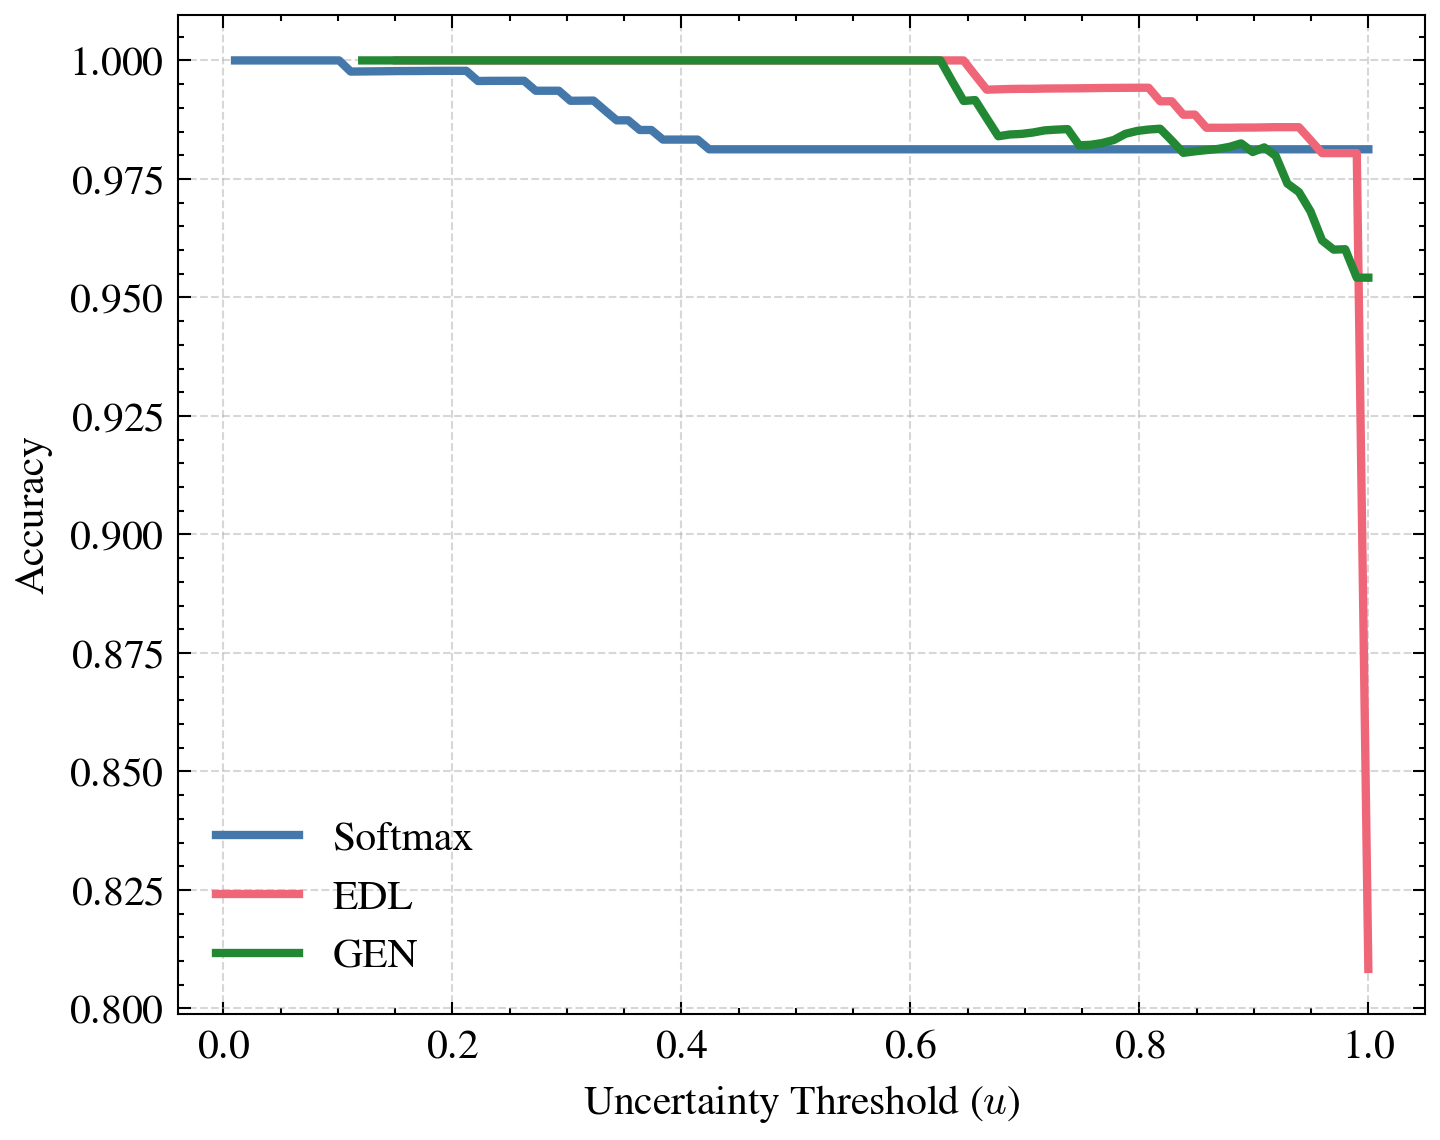

In [23]:
@torch.no_grad()
def compute_uncertainty_accuracy(
    model: torch.nn.Module,
    inference_fn: Callable,
    dataloader: torch.utils.data.DataLoader,
    device: torch.device,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Compute accuracy vs uncertainty curve for the given model and dataloader."""
    model.eval().to(device)

    all_uncertainties: list[torch.Tensor] = []
    all_correct: list[torch.Tensor] = []

    for x, y in dataloader:
        with torch.autocast(device_type=device.type, dtype=torch.float16):
            logits = model(x.to(device))

        pred, uncertainty, _ = inference_fn(logits.float())

        all_correct.append((pred == y.to(device)).detach())
        all_uncertainties.append(uncertainty.detach())

    all_correct_t = torch.cat(all_correct)
    all_uncertainties_t = torch.cat(all_uncertainties)

    thresholds = torch.linspace(0.0, 1.0, 100)
    accuracies = torch.full_like(thresholds, torch.nan, dtype=torch.float32)

    for i, t in enumerate(thresholds):
        mask = all_uncertainties_t <= t
        if mask.any():
            accuracies[i] = all_correct_t[mask].float().mean()

    return thresholds, accuracies


softmax_thresholds, softmax_accuracies = compute_uncertainty_accuracy(wi_har_model, _softmax_inference, test_dl, DEVICE)
edl_thresholds, edl_accuracies = compute_uncertainty_accuracy(edl_model, edl_inference, test_dl, DEVICE)
gen_thresholds, gen_accuracies = compute_uncertainty_accuracy(gen_model, gen_inference, test_dl, DEVICE)

plt.figure(figsize=(5, 4))

plt.plot(softmax_thresholds, softmax_accuracies, lw=2, label="Softmax")
plt.plot(edl_thresholds, edl_accuracies, lw=2, label="EDL")
plt.plot(gen_thresholds, gen_accuracies, lw=2, label="GEN")

plt.xlabel("Uncertainty Threshold ($u$)")
plt.ylabel("Accuracy")
plt.tick_params(axis="y")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "edl_thresholds.pdf")
plt.show()

## OOD Detection

Measure how well each model's uncertainty score separates in-distribution (ID) from out-of-distribution (OOD) samples using the AUC-ROC metric.

A sample with uncertainty exceeding what is expected on training data (modelled as a Beta distribution) is flagged as OOD.

### Beta Distribution

In [24]:
@torch.no_grad()
def collect_uncertainties(
    model: torch.nn.Module,
    inference_fn: Callable,
    dataloader: torch.utils.data.DataLoader,
    device: torch.device,
) -> np.ndarray:
    """Collect uncertainty scores for all samples in a dataloader.

    Arguments:
        model: The trained model to evaluate.
        inference_fn: A function that takes the model's logits and returns
            (predictions, uncertainties, probabilities).
        dataloader: DataLoader for the dataset to collect uncertainties from.
        device: Device to run inference on.

    Returns:
        A NumPy array of uncertainty scores for all samples in the dataloader.

    """
    all_uncertainties: list[torch.Tensor] = []

    for x, _ in dataloader:
        with torch.autocast(device_type=device.type, dtype=torch.float16):
            logits = model(x.to(device, non_blocking=True))
        _, uncertainty, _ = inference_fn(logits.float())
        all_uncertainties.append(uncertainty)

    return torch.cat(all_uncertainties).cpu().numpy()


@torch.no_grad()
def fit_beta(
    model: fusion.Delayed,
    inference_fn: Callable,
    train_dl: torch.utils.data.DataLoader,
    device: torch.device,
) -> tuple[float, float]:
    """Fit a Beta distribution to all in-distribution training uncertainty scores.

    Arguments:
        model: The trained model to evaluate.
        inference_fn: Returns (predictions, uncertainties, probabilities).
        train_dl: DataLoader for the training set.
        device: Device to run inference on.

    Returns:
        Tuple (a, b) — fitted Beta shape parameters.

    """
    model.eval()
    uncertainties = collect_uncertainties(model, inference_fn, train_dl, device)
    uncertainties = uncertainties.clip(1e-6, 1 - 1e-6)
    m = uncertainties.mean()
    v = uncertainties.var()
    common = m * (1 - m) / v - 1
    return float(m * common), float((1 - m) * common)


def bayesian_score(
    uncertainties: np.ndarray,
    a: float,
    b: float,
    p_id: float = 0.5,
) -> np.ndarray:
    """Compute 1 - P(ID|u) via Bayes theorem as the OOD score.

    P(ID|u) = P(u|ID) * P(ID) / (P(u|ID) * P(ID) + P(u|OOD) * P(OOD))

    where:
      P(u|ID)  = Beta(u; a, b)  — fitted on training ID uncertainties
      P(u|OOD) = Uniform(0, 1) = 1  — uninformative OOD model
      P(ID) = p_id, P(OOD) = 1 - p_id  — prior (default: equal)

    A high score means the sample looks OOD.

    Arguments:
        uncertainties: Array of uncertainty values in [0, 1].
        a: Beta shape parameter alpha.
        b: Beta shape parameter beta.
        p_id: Prior probability of a sample being in-distribution.

    Returns:
        Array of OOD scores in [0, 1].

    """
    uncertainties = np.clip(uncertainties, 1e-6, 1 - 1e-6)  # prevent boundary blow-up
    p_u_id = beta_dist.cdf(uncertainties+1e-6, a, b) - beta_dist.cdf(uncertainties-1e-6, a, b)
    p_u_ood = np.ones_like(p_u_id) * 2e-6
    p_ood = 1.0 - p_id

    denom = p_u_id * p_id + p_u_ood * p_ood
    p_id_given_u = (p_u_id * p_id) / denom
    return 1.0 - p_id_given_u

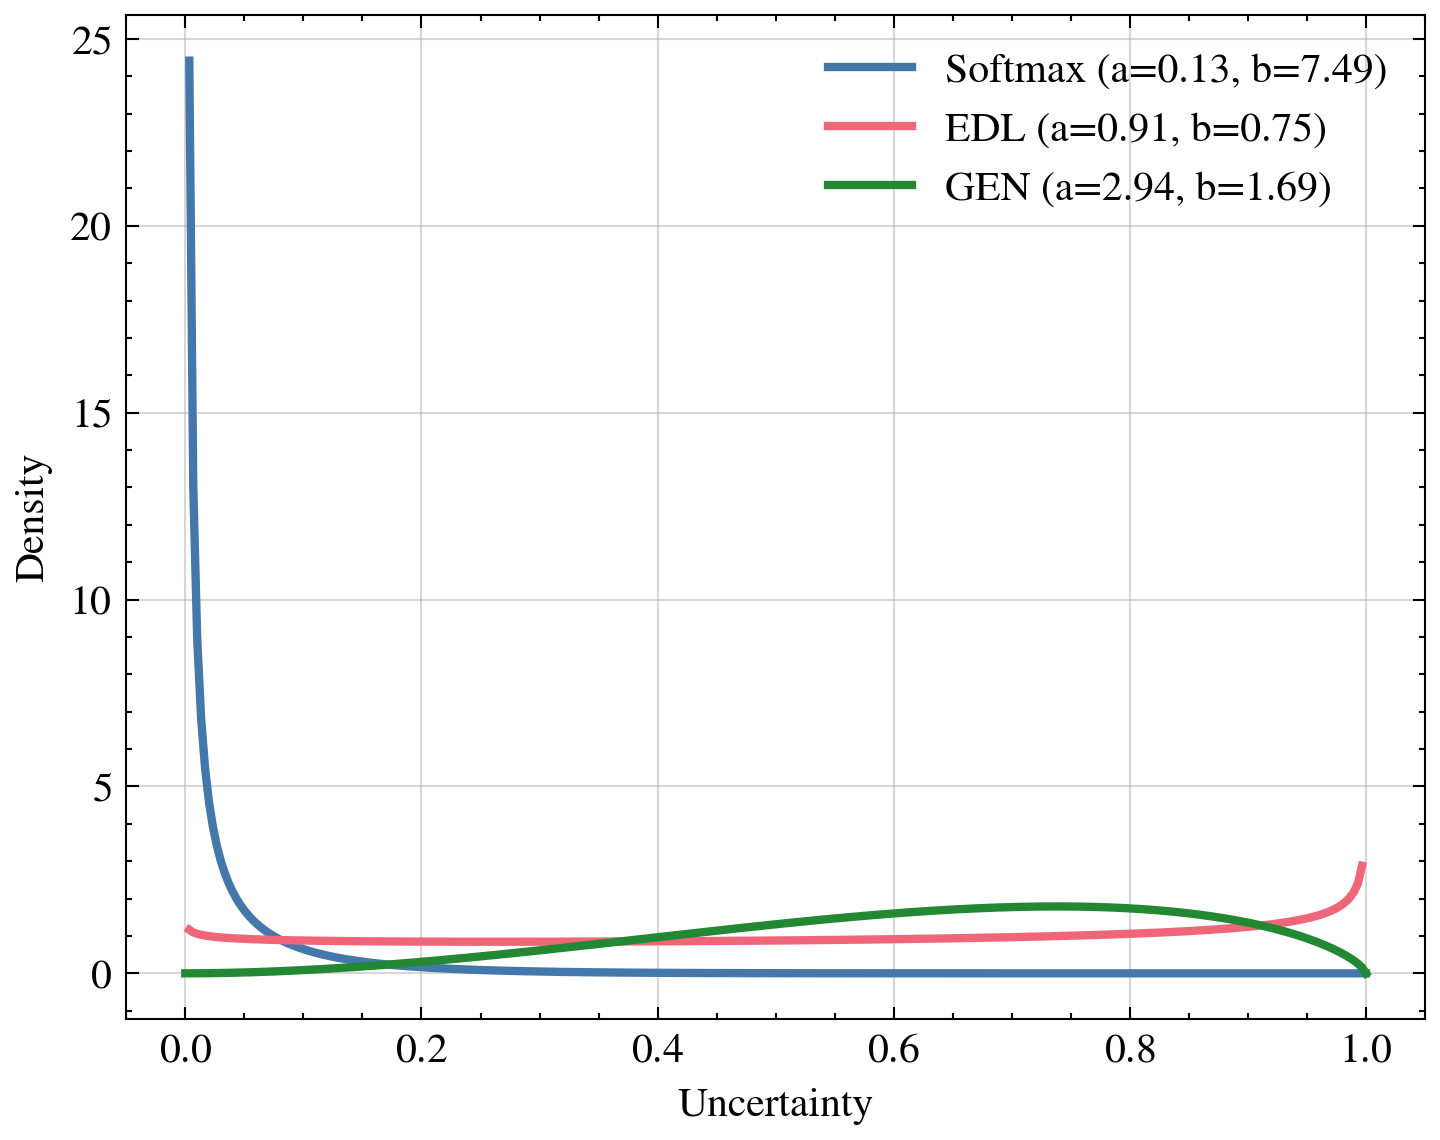

In [25]:
models_list = [
    ("Softmax", wi_har_model, _softmax_inference),
    ("EDL", edl_model, edl_inference),
    ("GEN", gen_model, gen_inference),
]
x = np.linspace(0, 1, 300)

params = {
    model_name: fit_beta(model, inference_fn, train_dl, DEVICE) for model_name, model, inference_fn in models_list
}

plt.figure(figsize=(5, 4))
plt.plot(
    x,
    beta_dist.pdf(x, *params["Softmax"]),
    lw=2,
    label=f"Softmax (a={params['Softmax'][0]:.2f}, b={params['Softmax'][1]:.2f})",
)
plt.plot(x, beta_dist.pdf(x, *params["EDL"]), lw=2, label=f"EDL (a={params['EDL'][0]:.2f}, b={params['EDL'][1]:.2f})")
plt.plot(x, beta_dist.pdf(x, *params["GEN"]), lw=2, label=f"GEN (a={params['GEN'][0]:.2f}, b={params['GEN'][1]:.2f})")
plt.xlabel("Uncertainty")
plt.ylabel("Density")
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "beta_fits.pdf")
plt.show()

ID


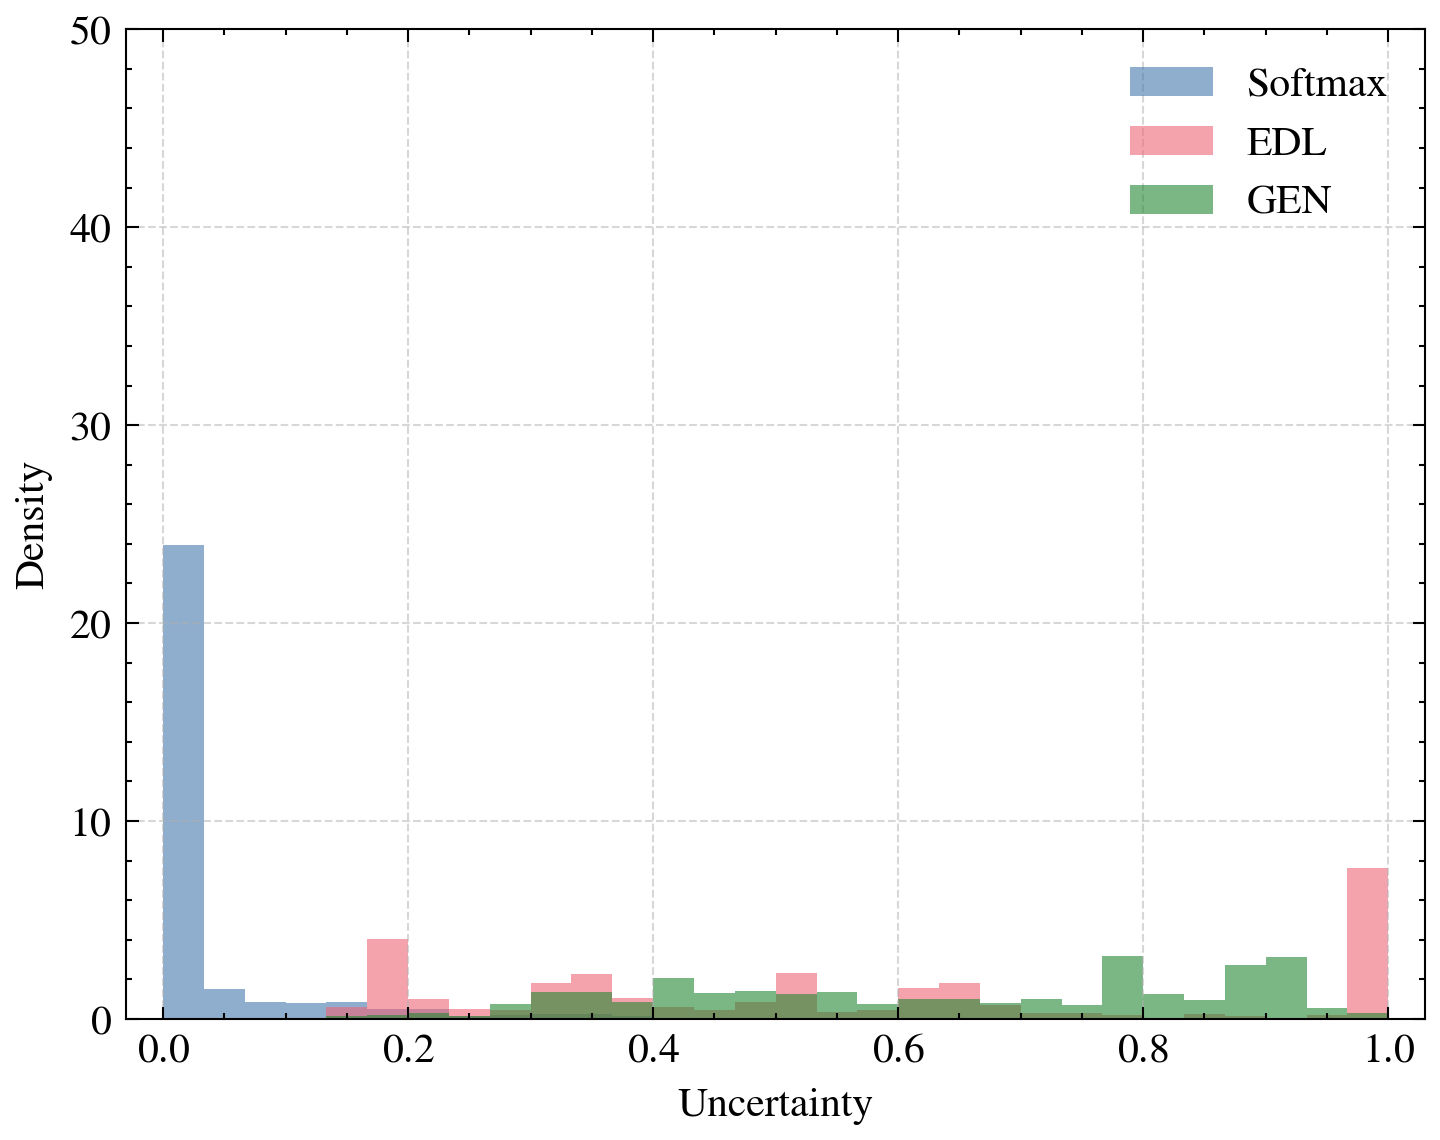

S1b


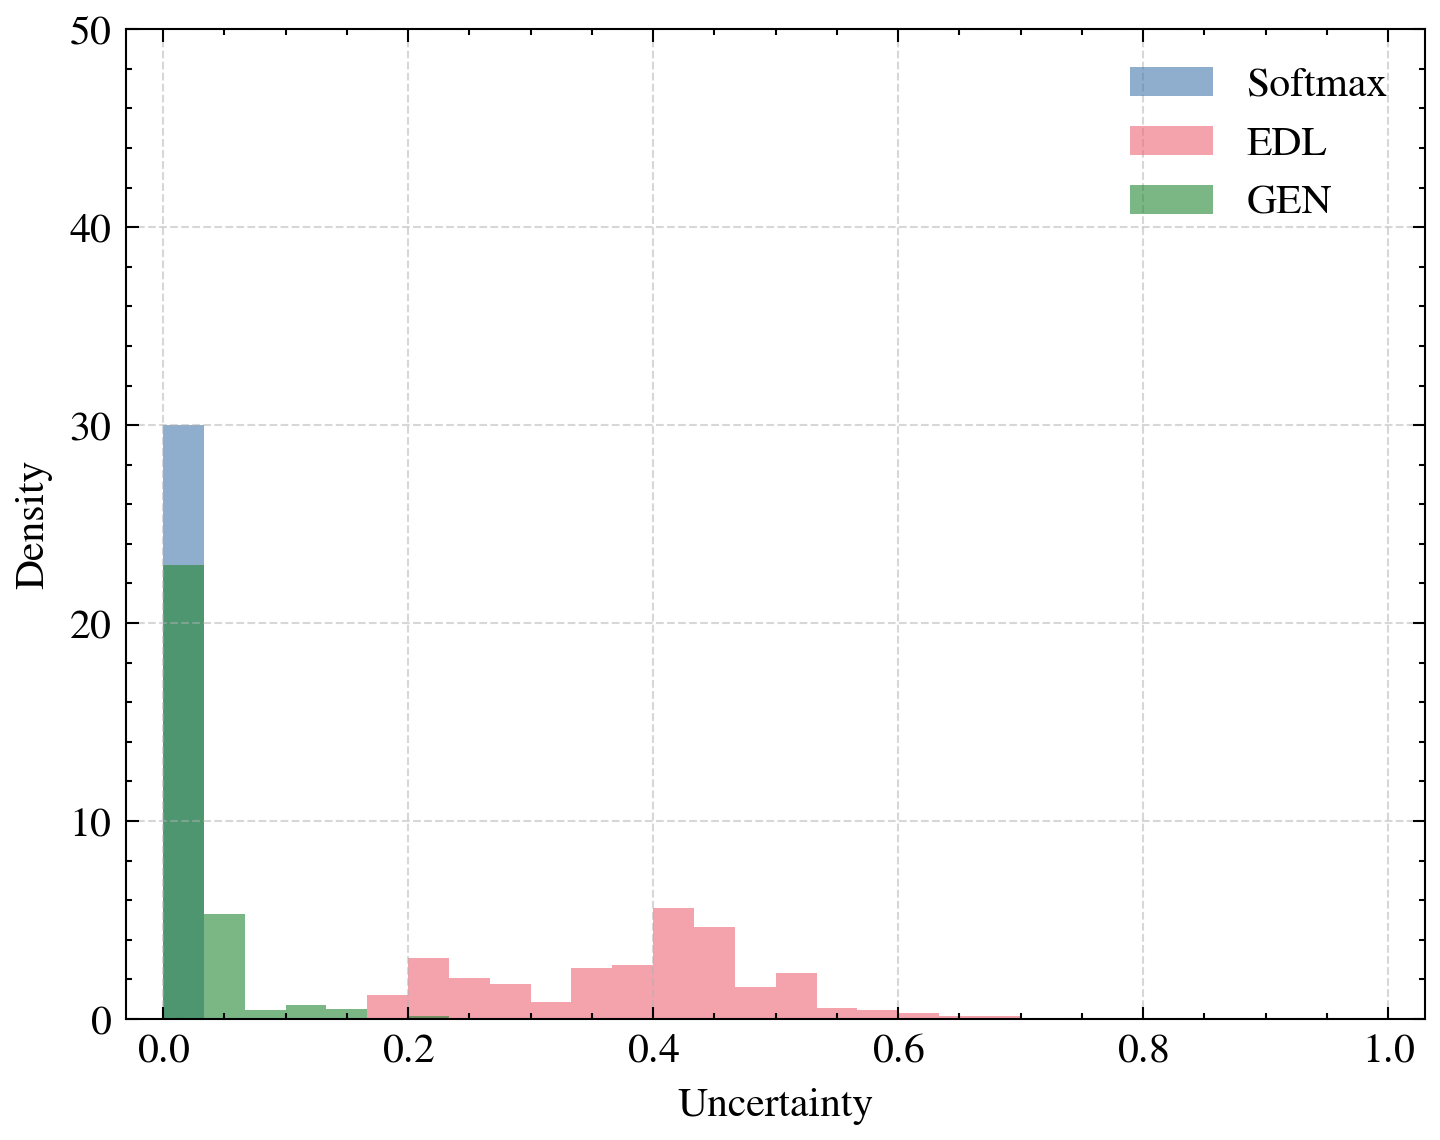

S1c


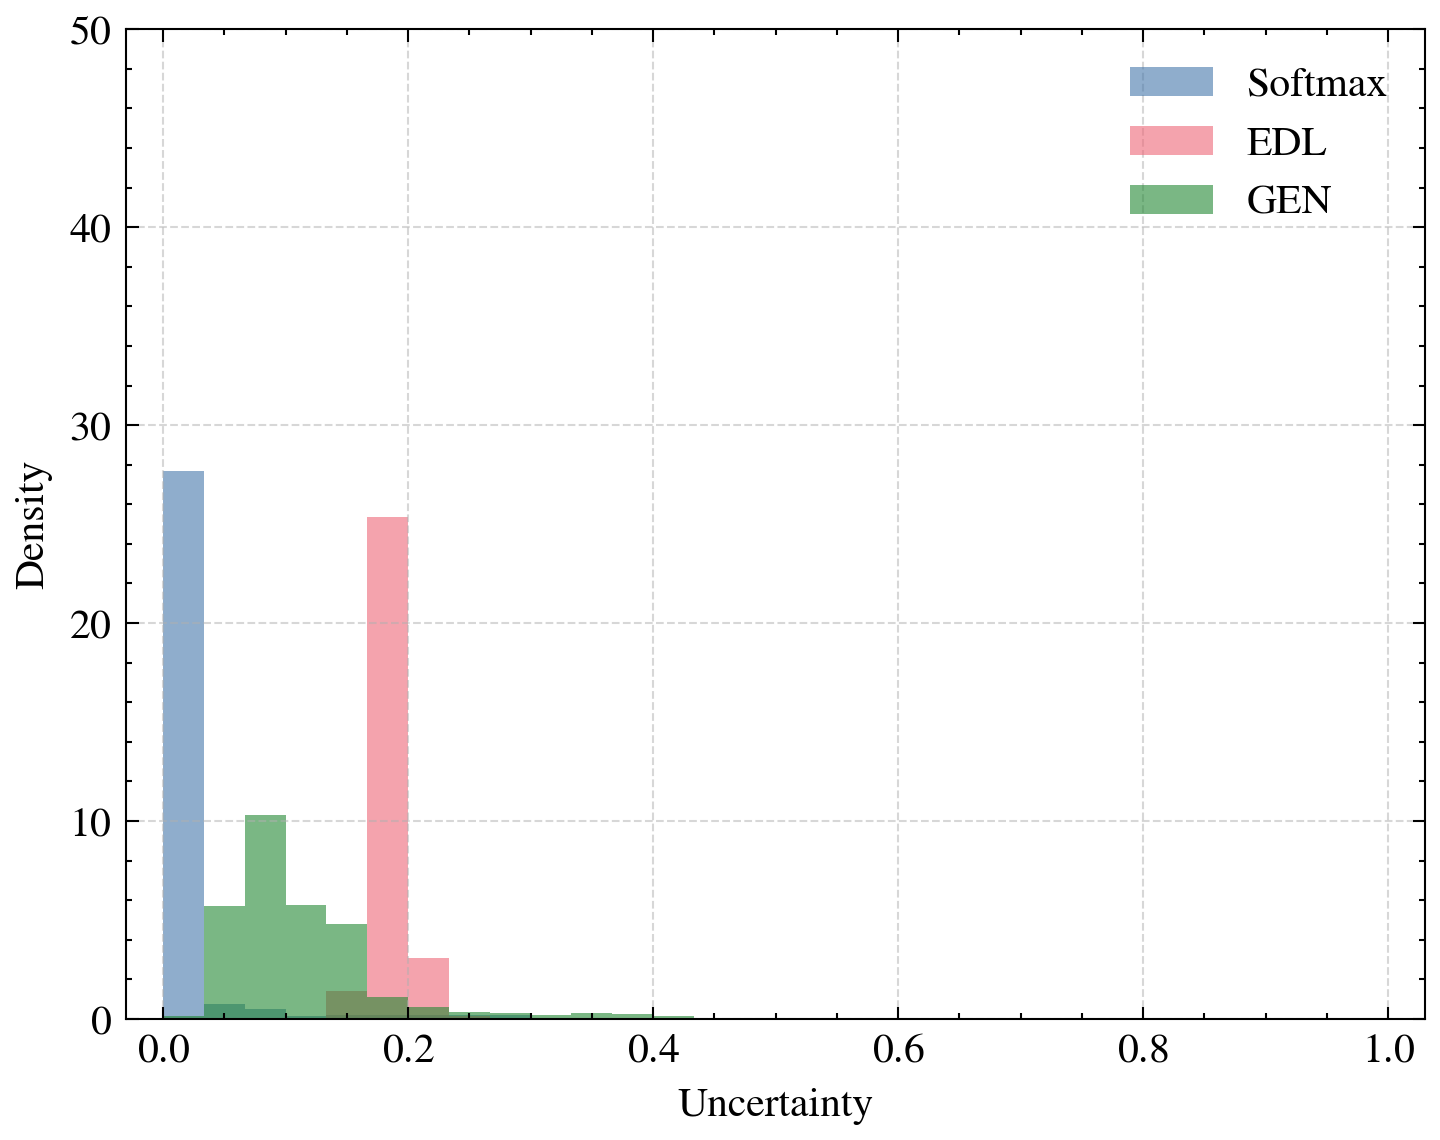

S2a


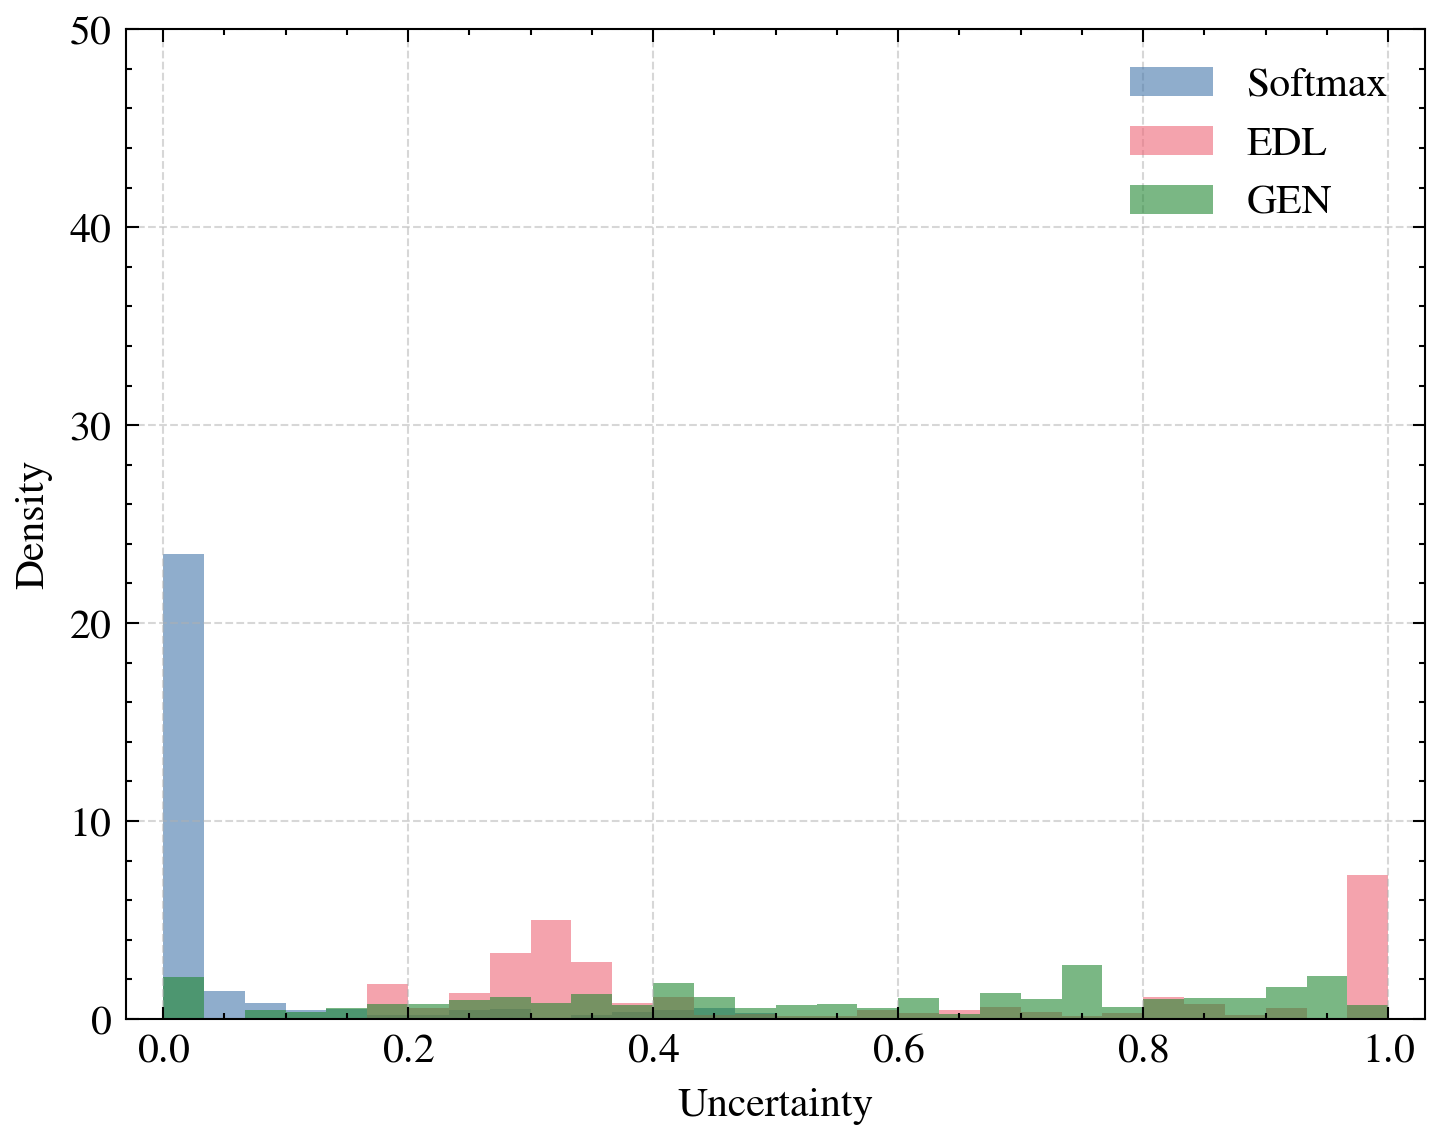

S2b


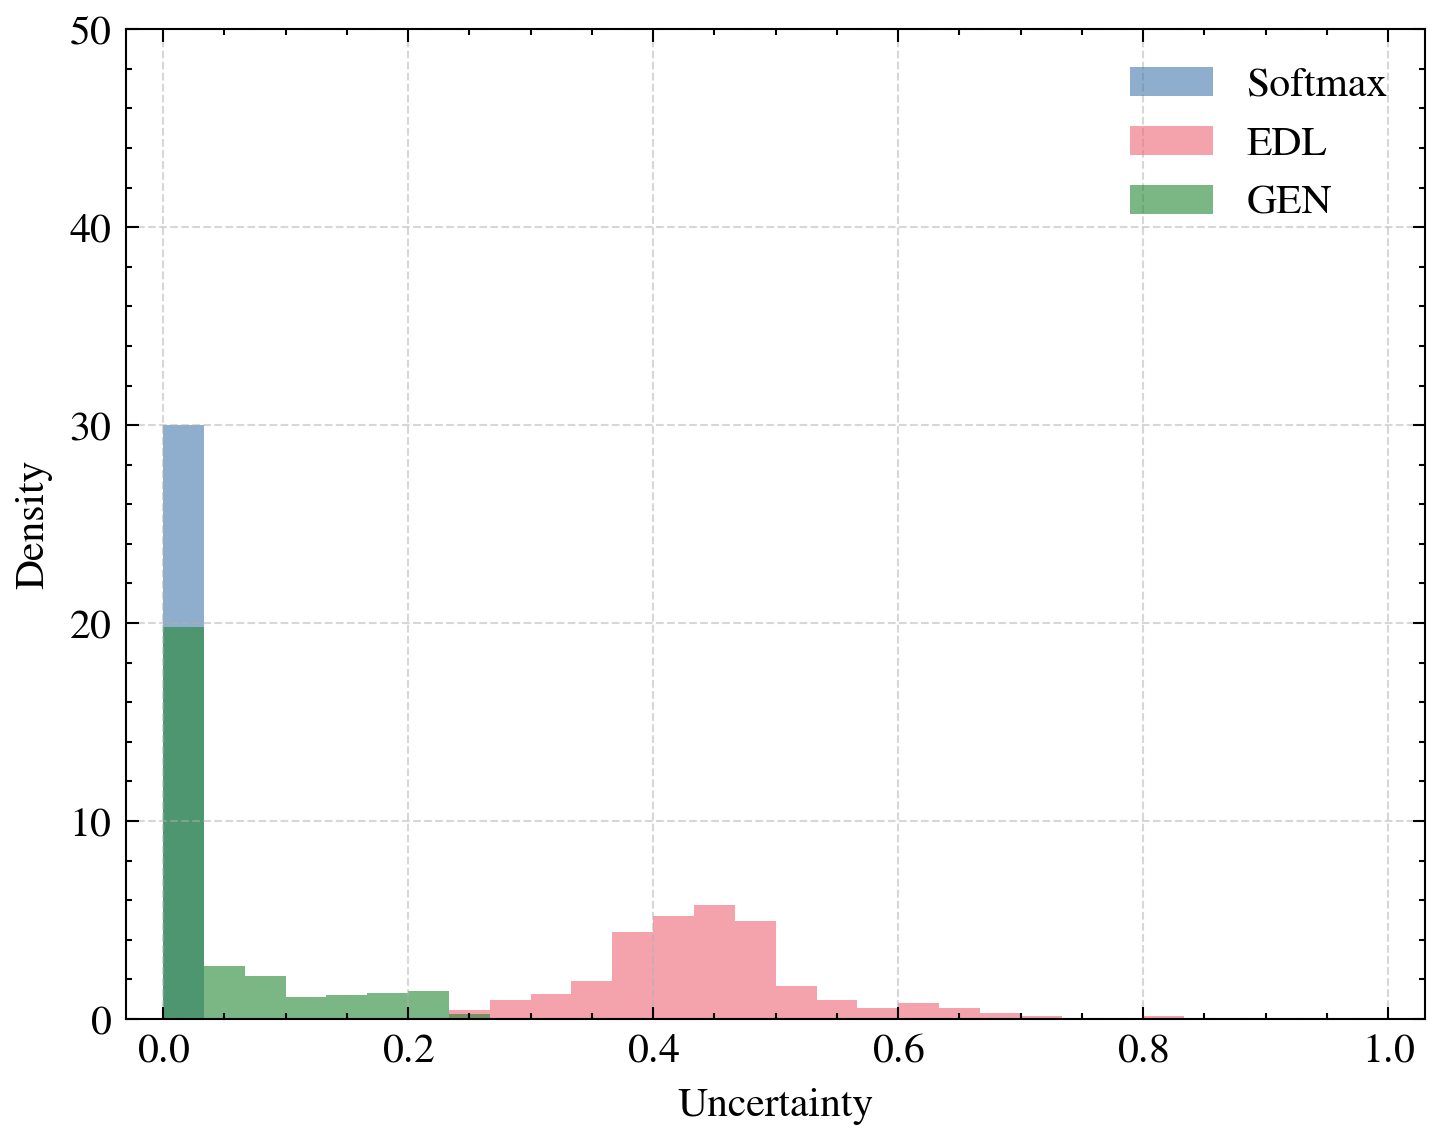

S2c


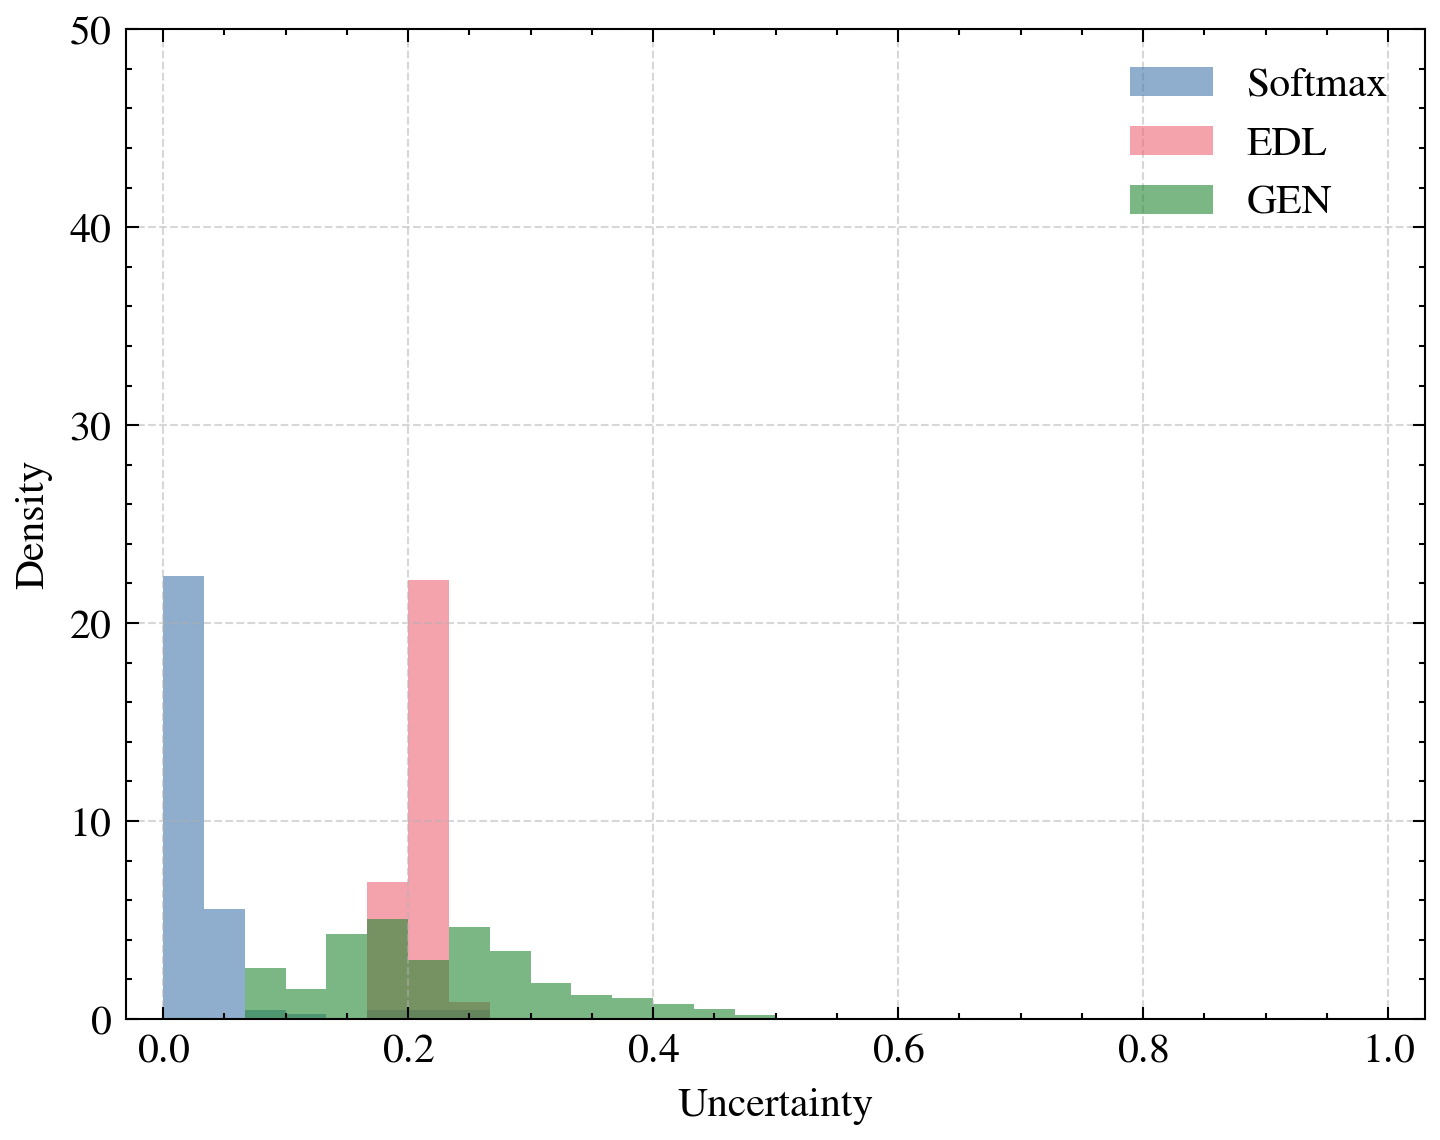

S4a


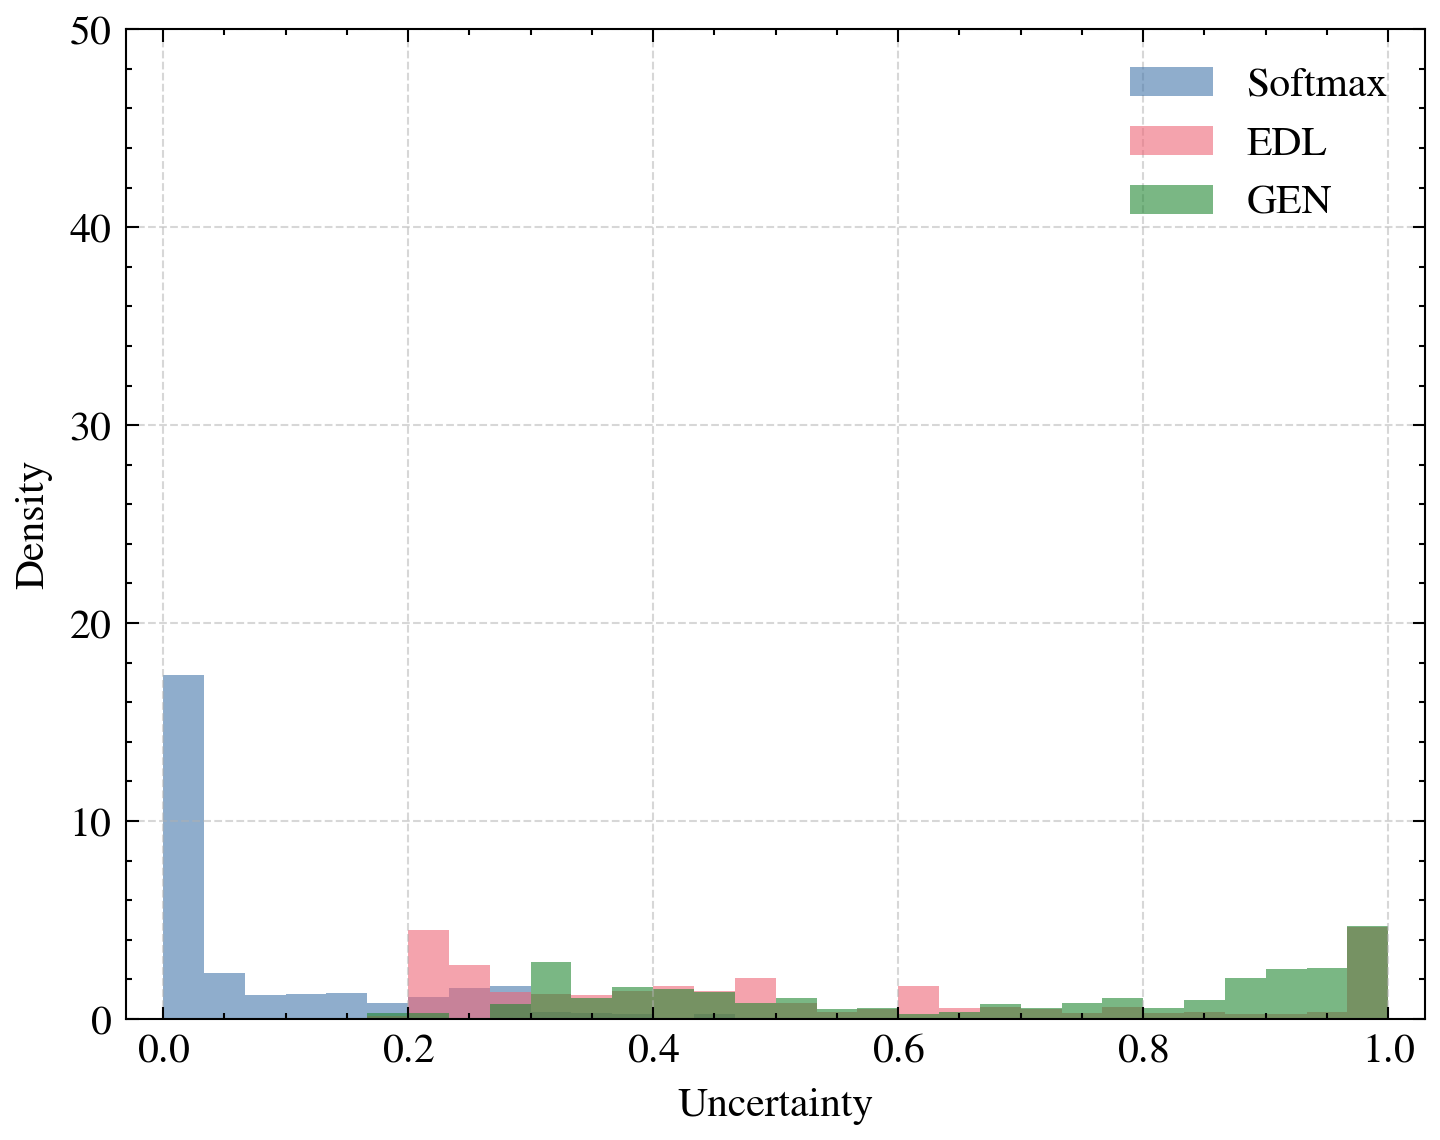

S4b


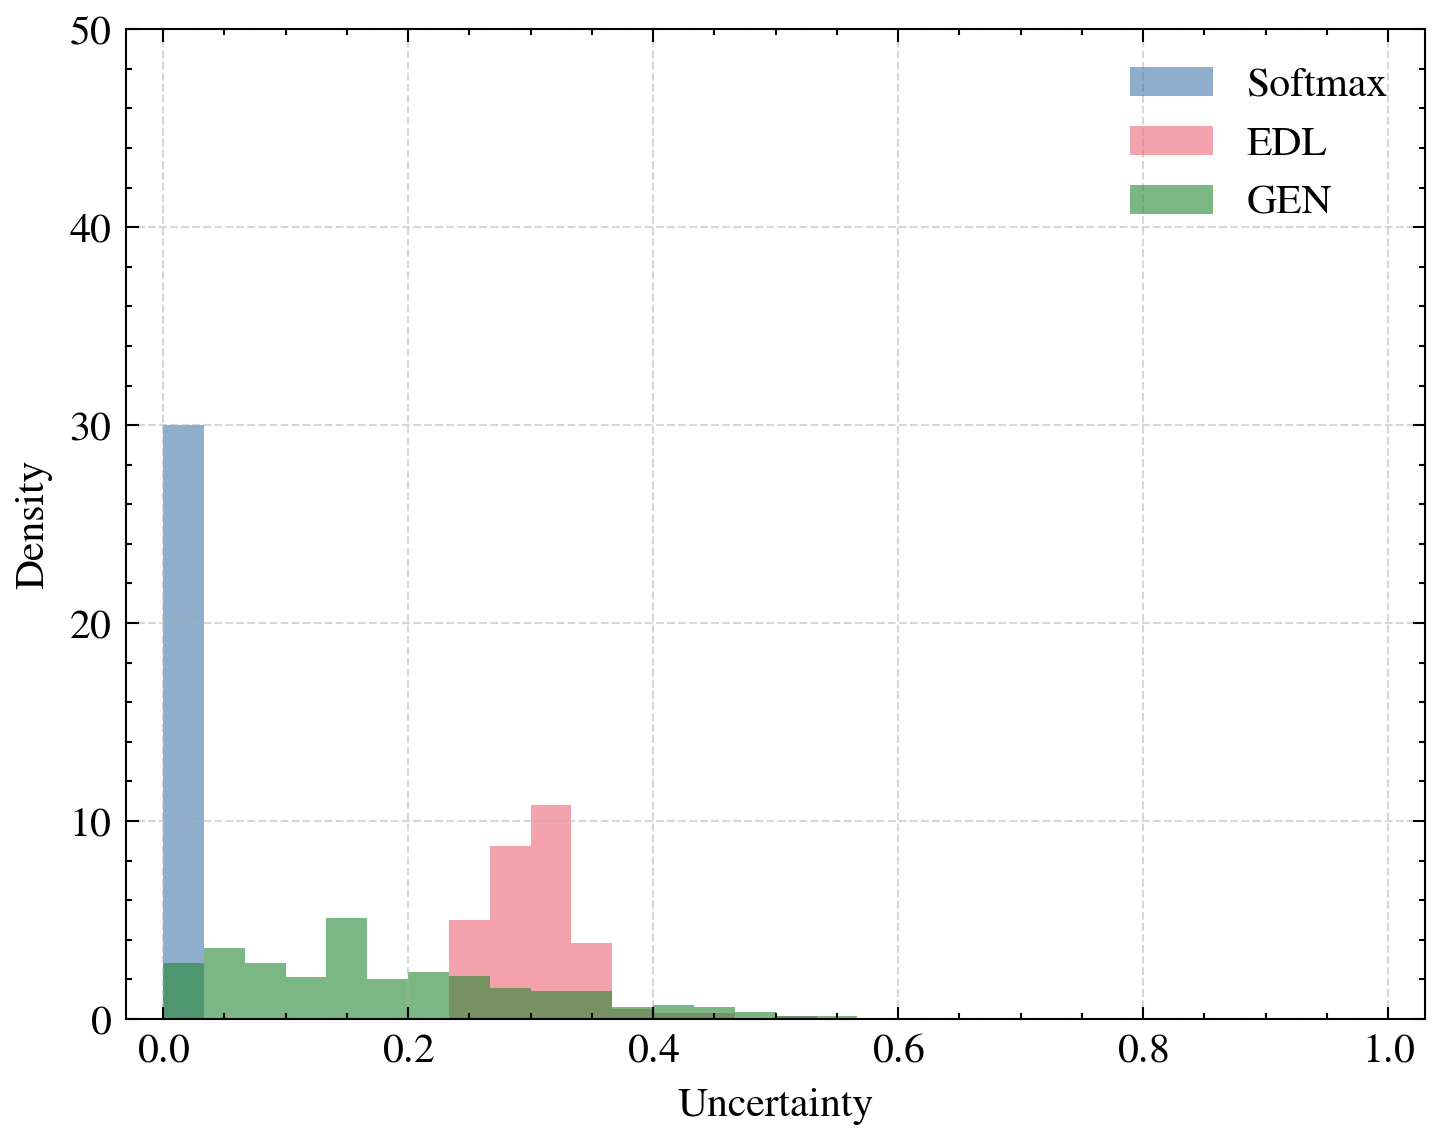

S4c


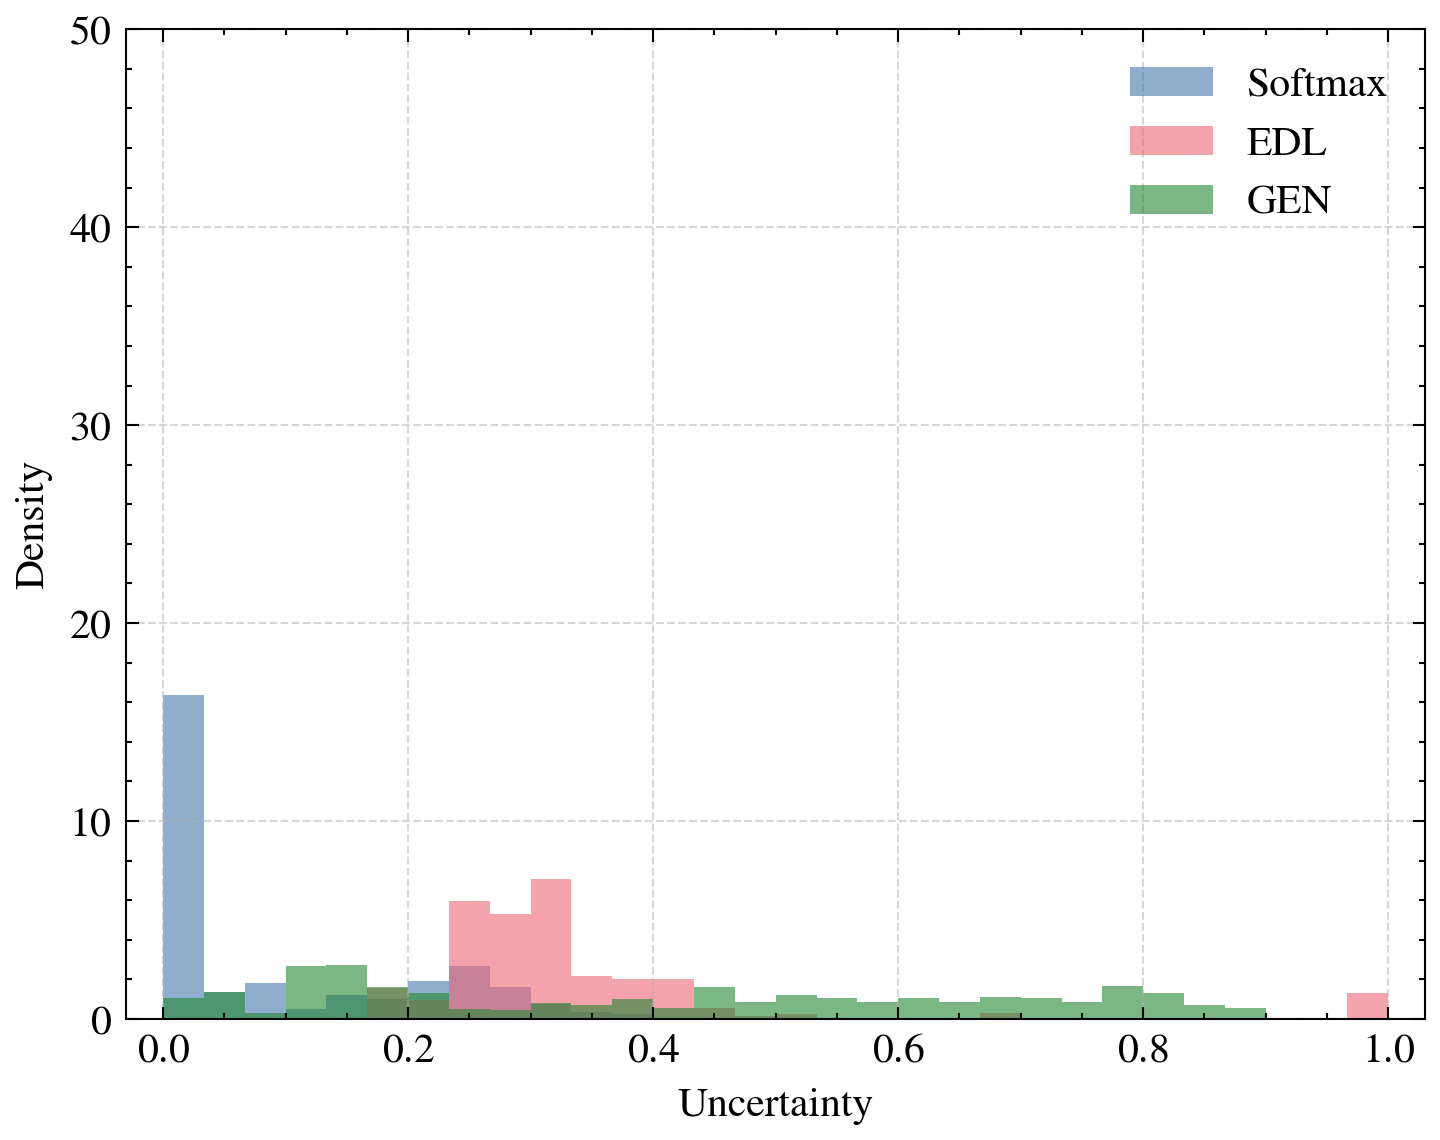

S6a


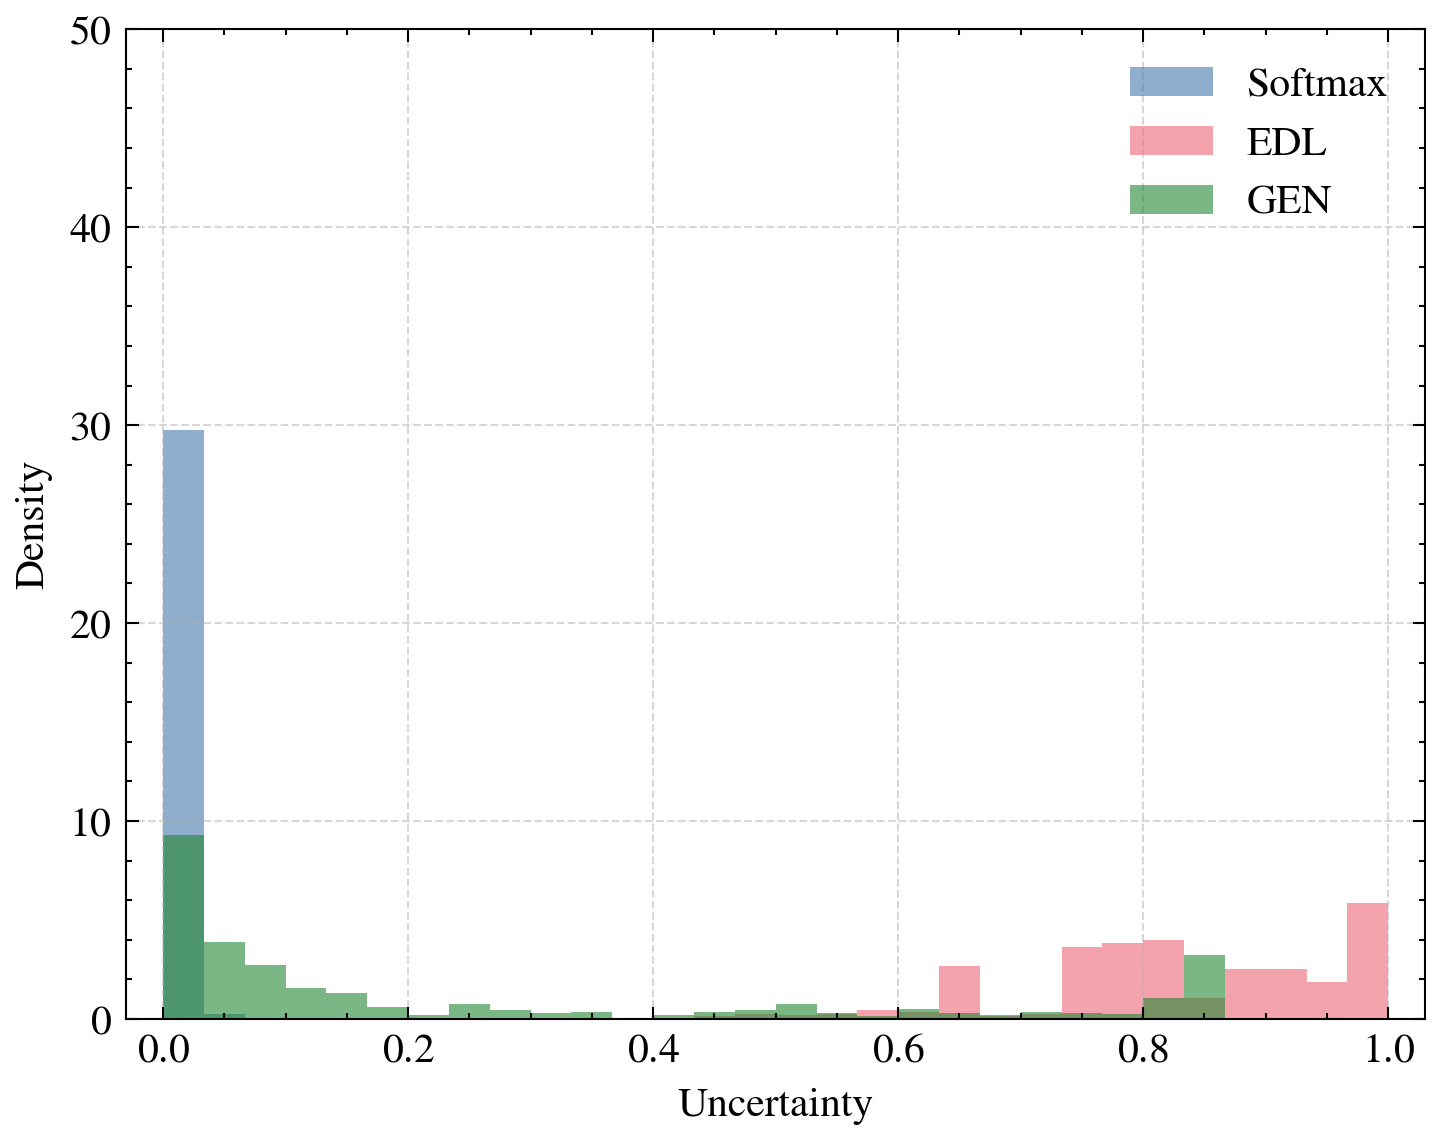

S6b


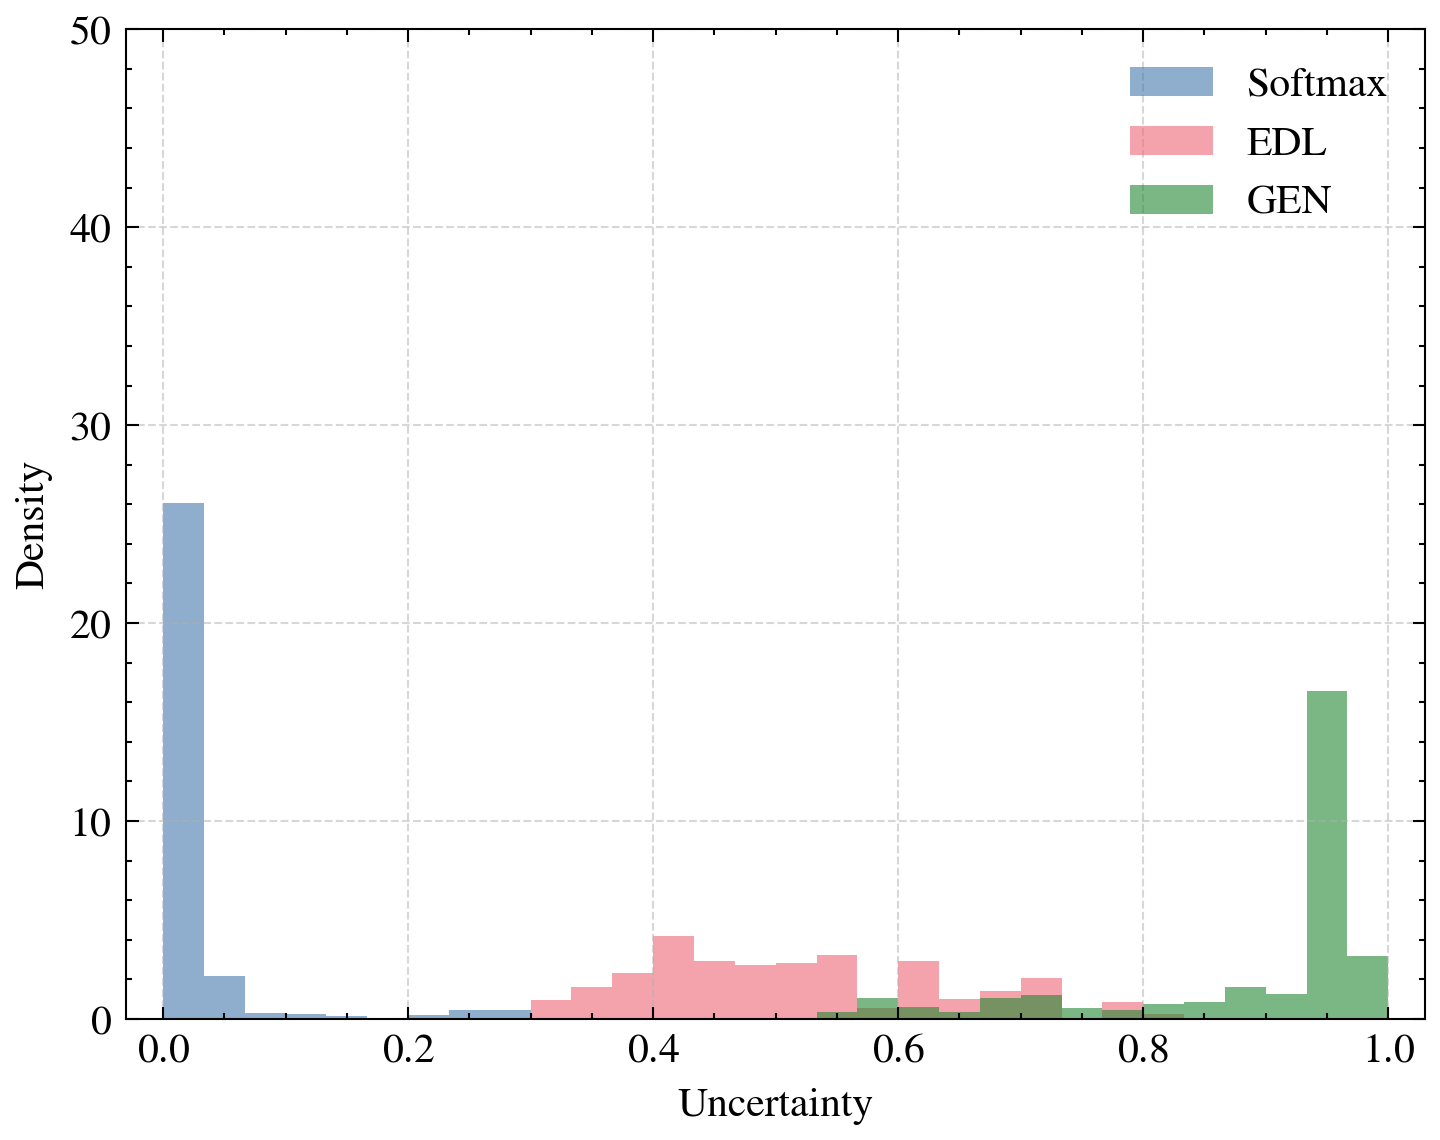

S6c


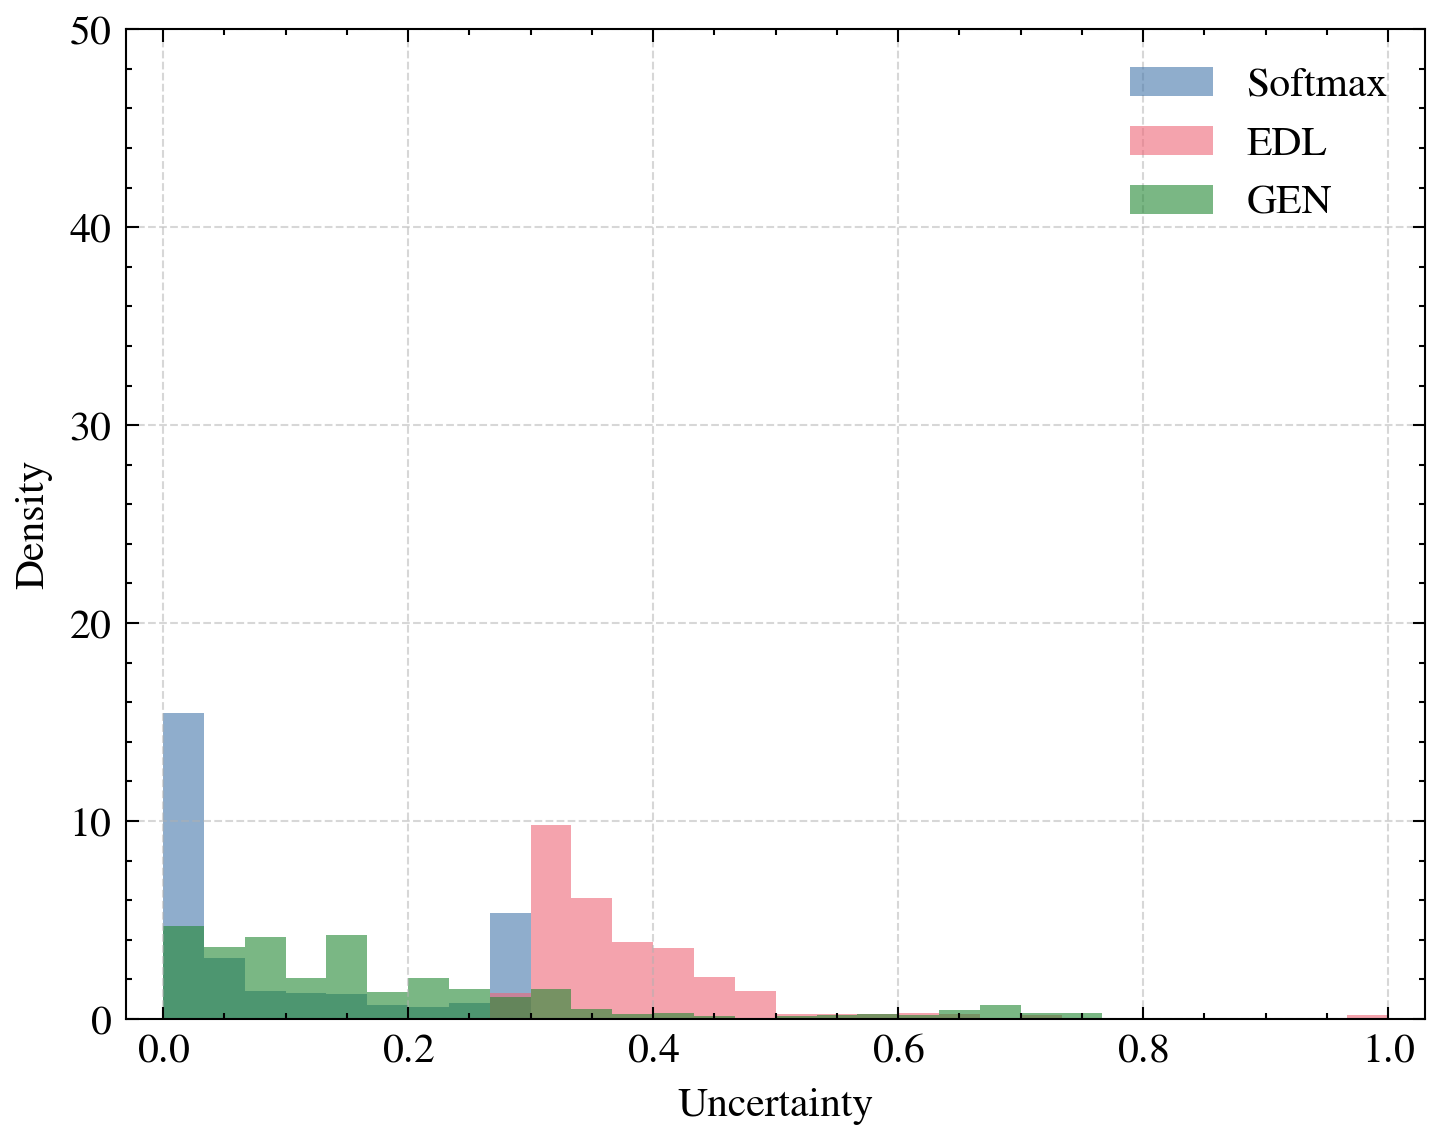

In [26]:
ood_datasets = [(ds.stem, get_ood_dl(ds)) for ds in OOD_DATASETS]

for ood_name, ood_dl in [("ID", test_dl), *ood_datasets]:
    print(ood_name)
    plt.figure(figsize=(5, 4))

    bin_edges = np.linspace(0.0, 1.0, 31)

    for model_name, model_obj, inference_fn in models_list:
        ood_uncertainties = collect_uncertainties(model_obj, inference_fn, ood_dl, DEVICE)
        plt.hist(
            ood_uncertainties,
            bins=bin_edges.tolist(),
            range=(0.0, 1.0),
            alpha=0.6,
            label=model_name,
            density=True,
        )

    plt.xlabel("Uncertainty")
    plt.xlim(-0.03, 1.03)
    plt.ylabel("Density")
    plt.ylim(0, 50)
    plt.legend()
    plt.grid(True, alpha=0.5, linestyle="--")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"uncertainty_hist_{ood_name}.pdf")
    plt.show()

ID


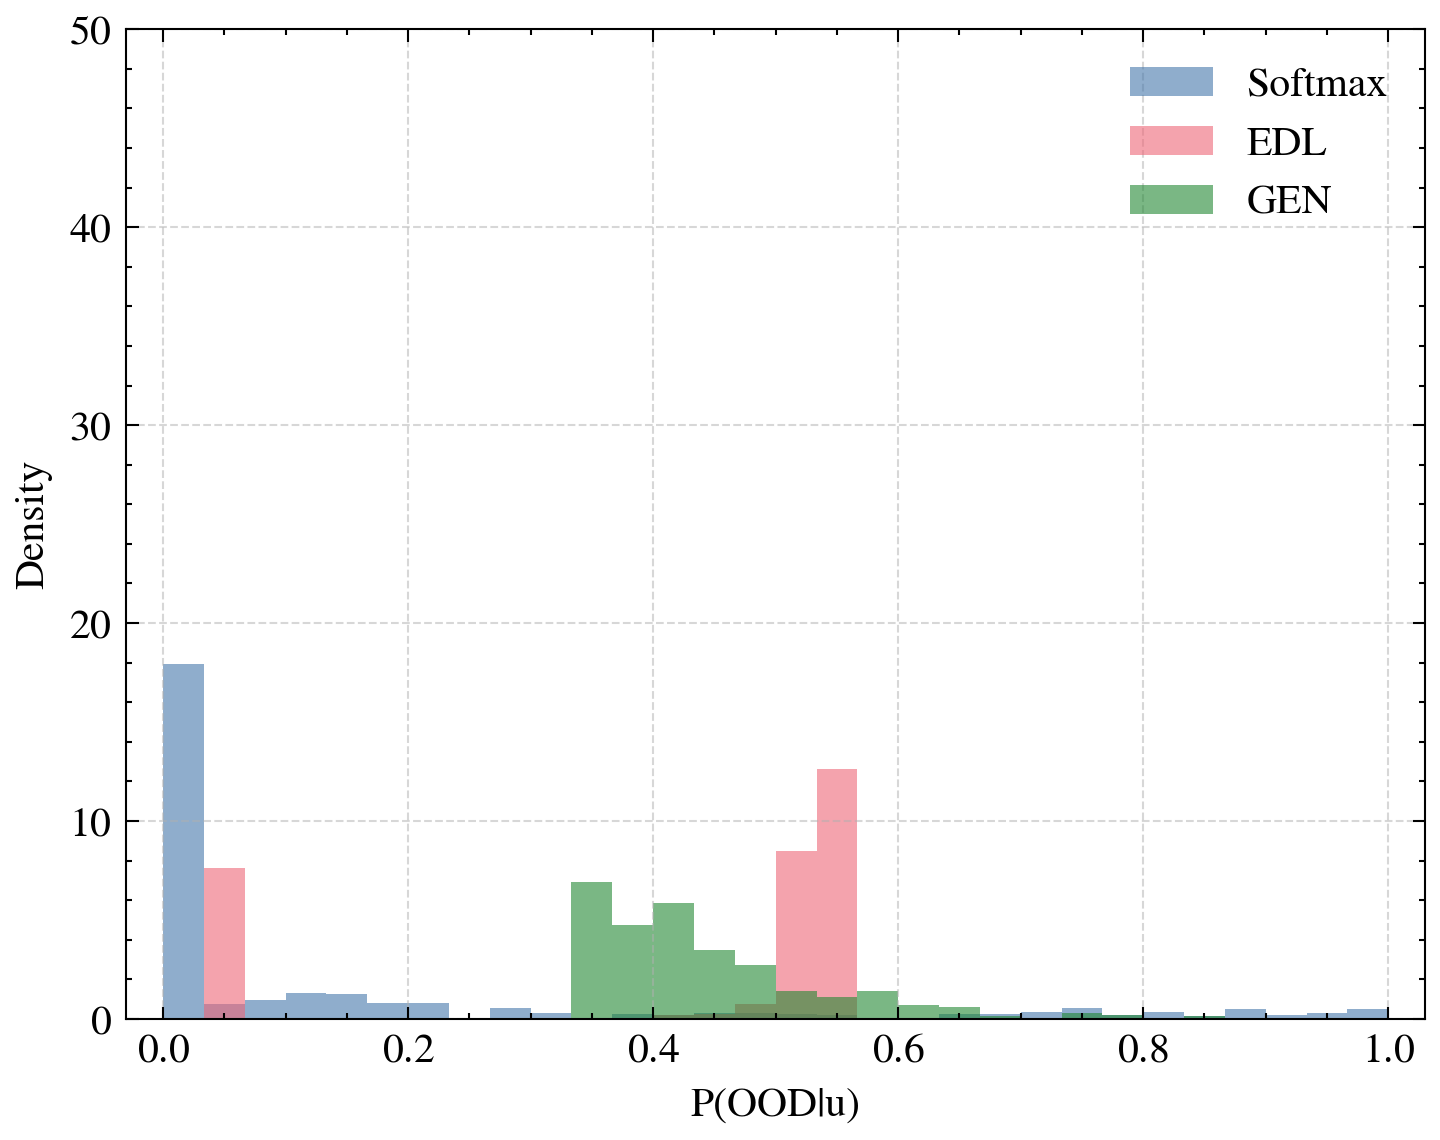

S1b


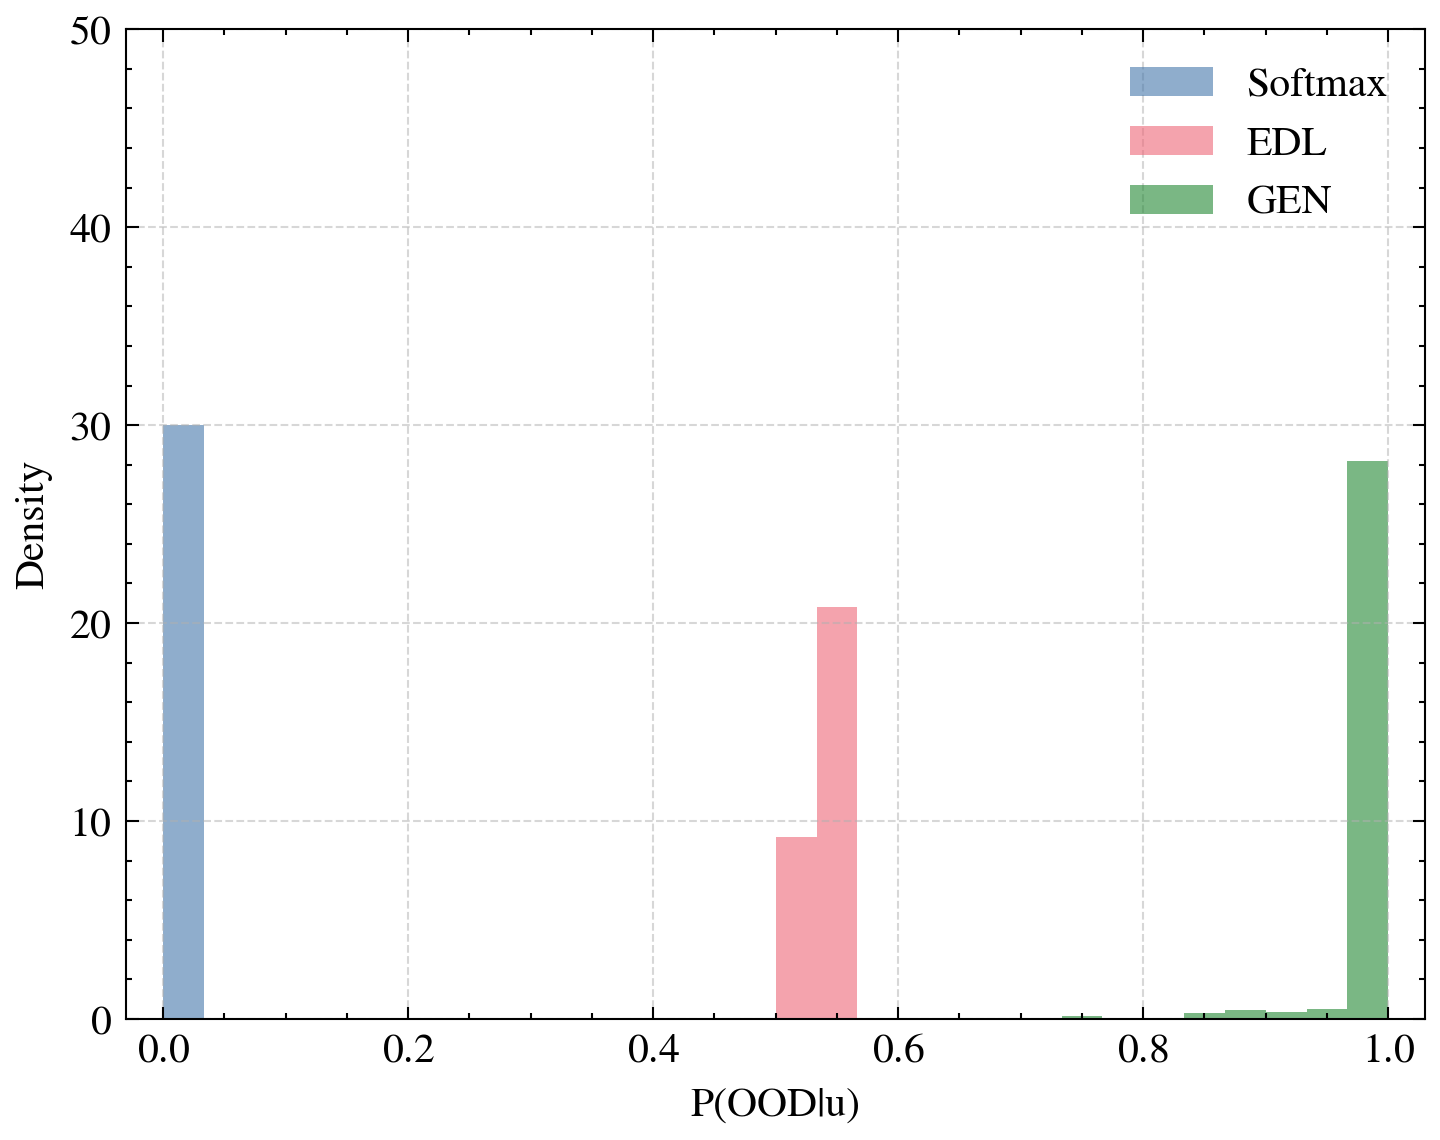

S1c


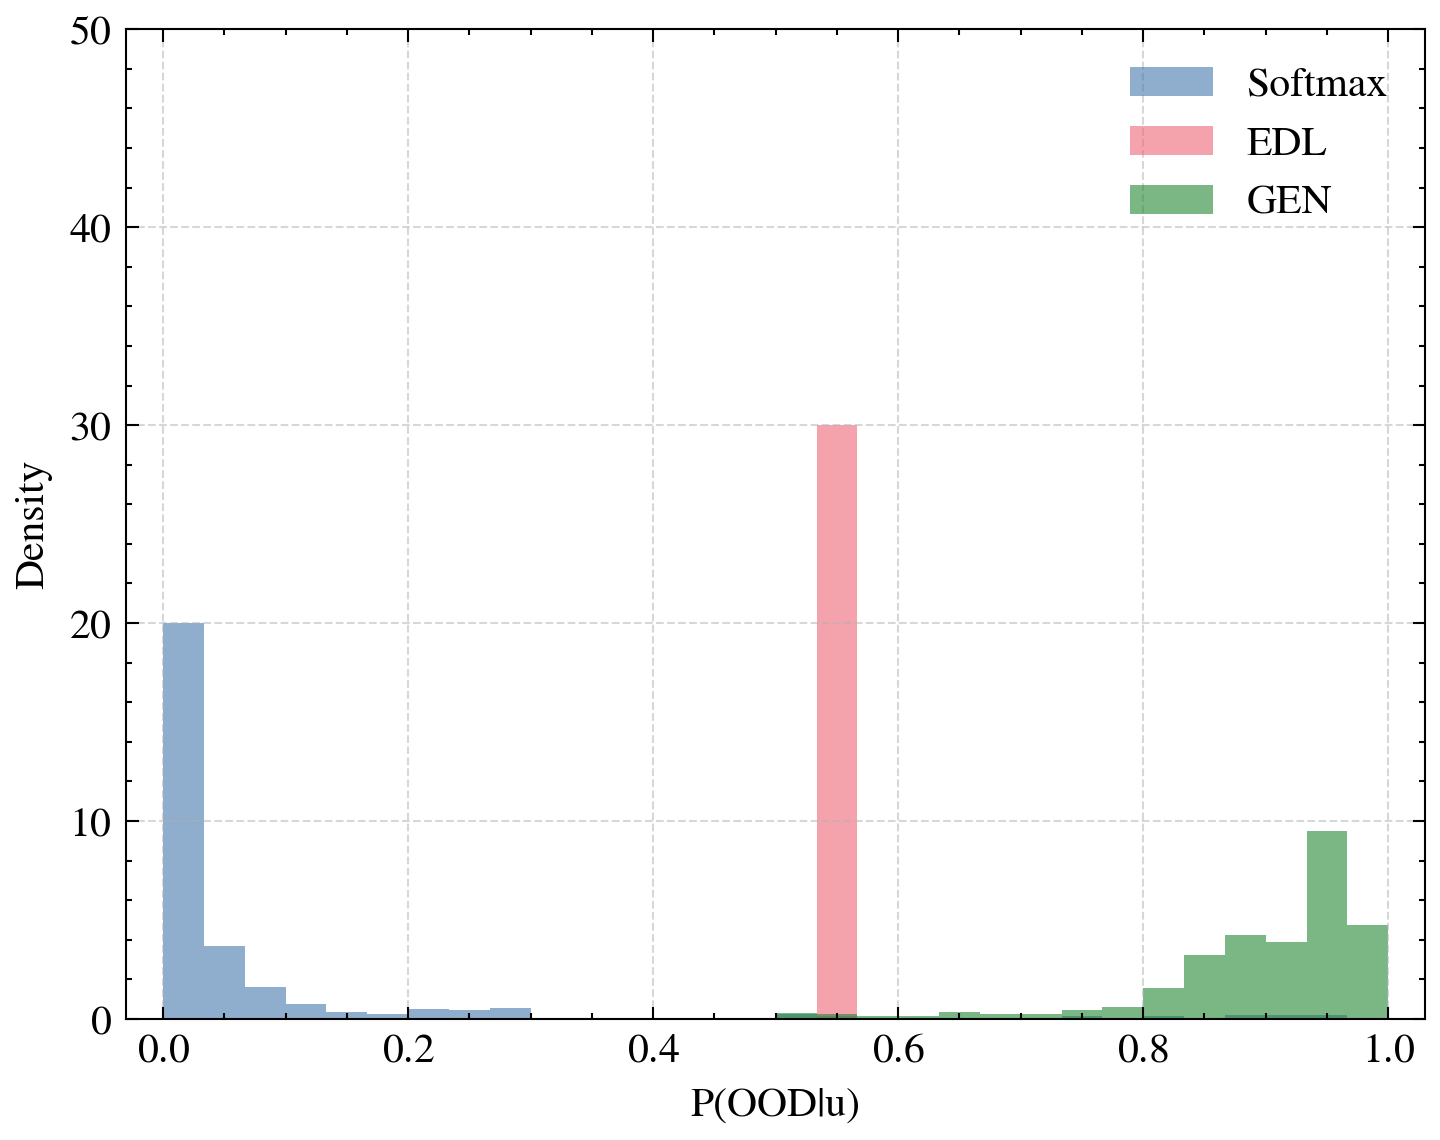

S2a


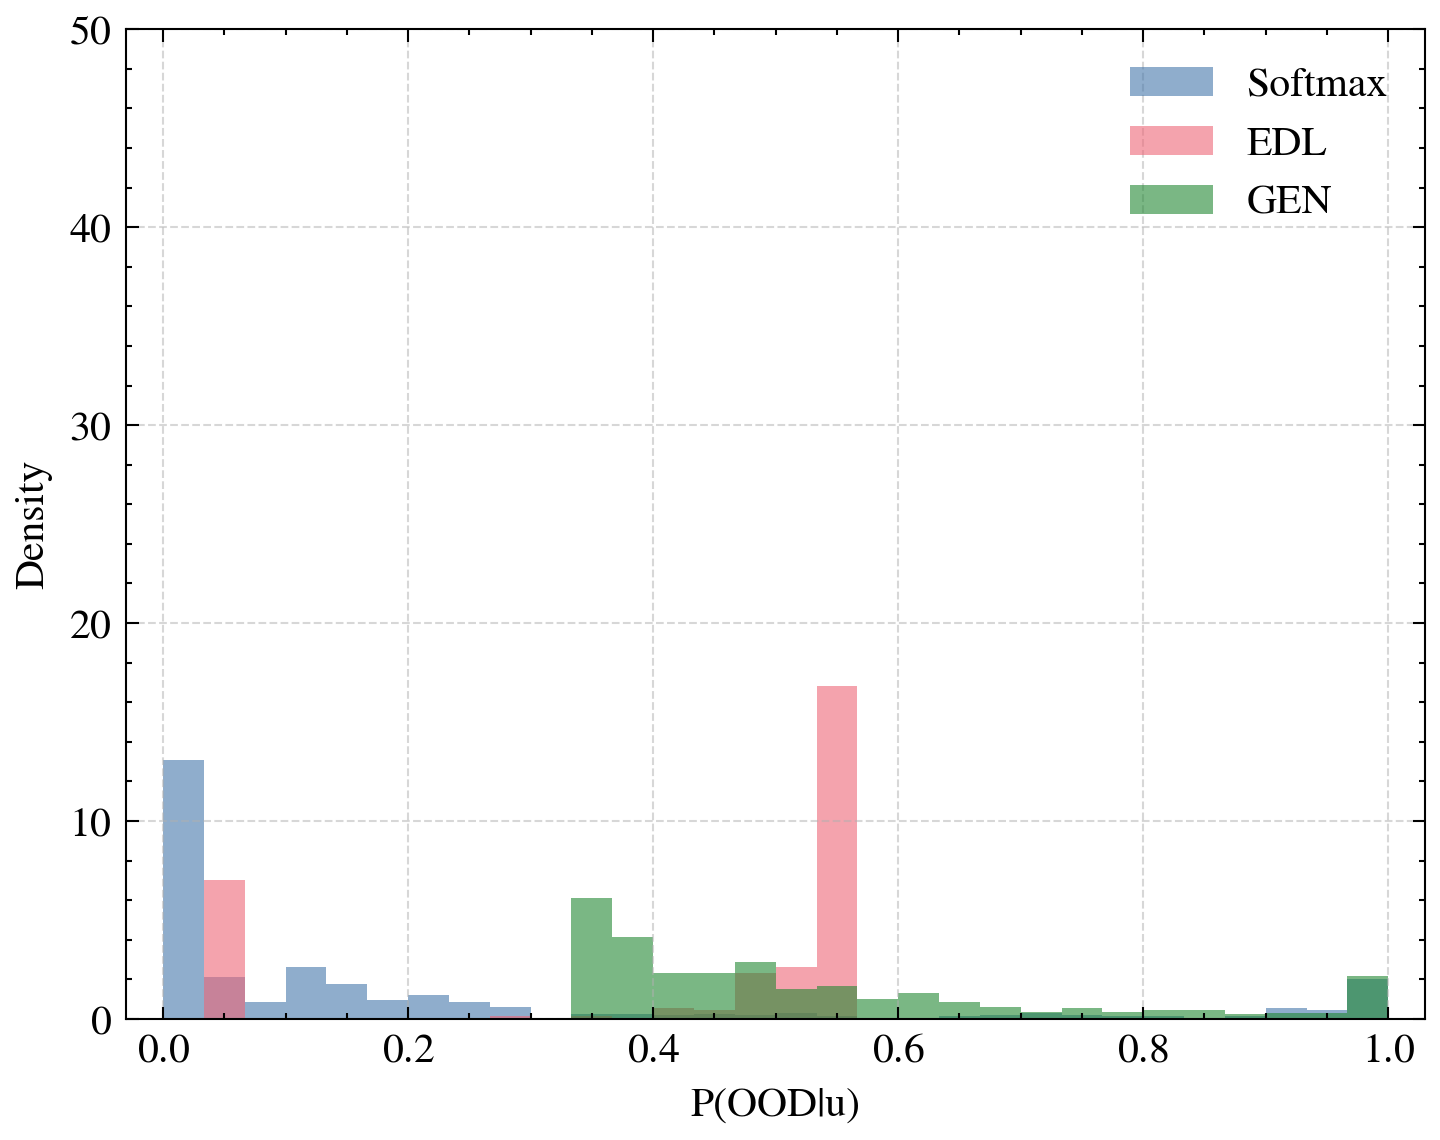

S2b


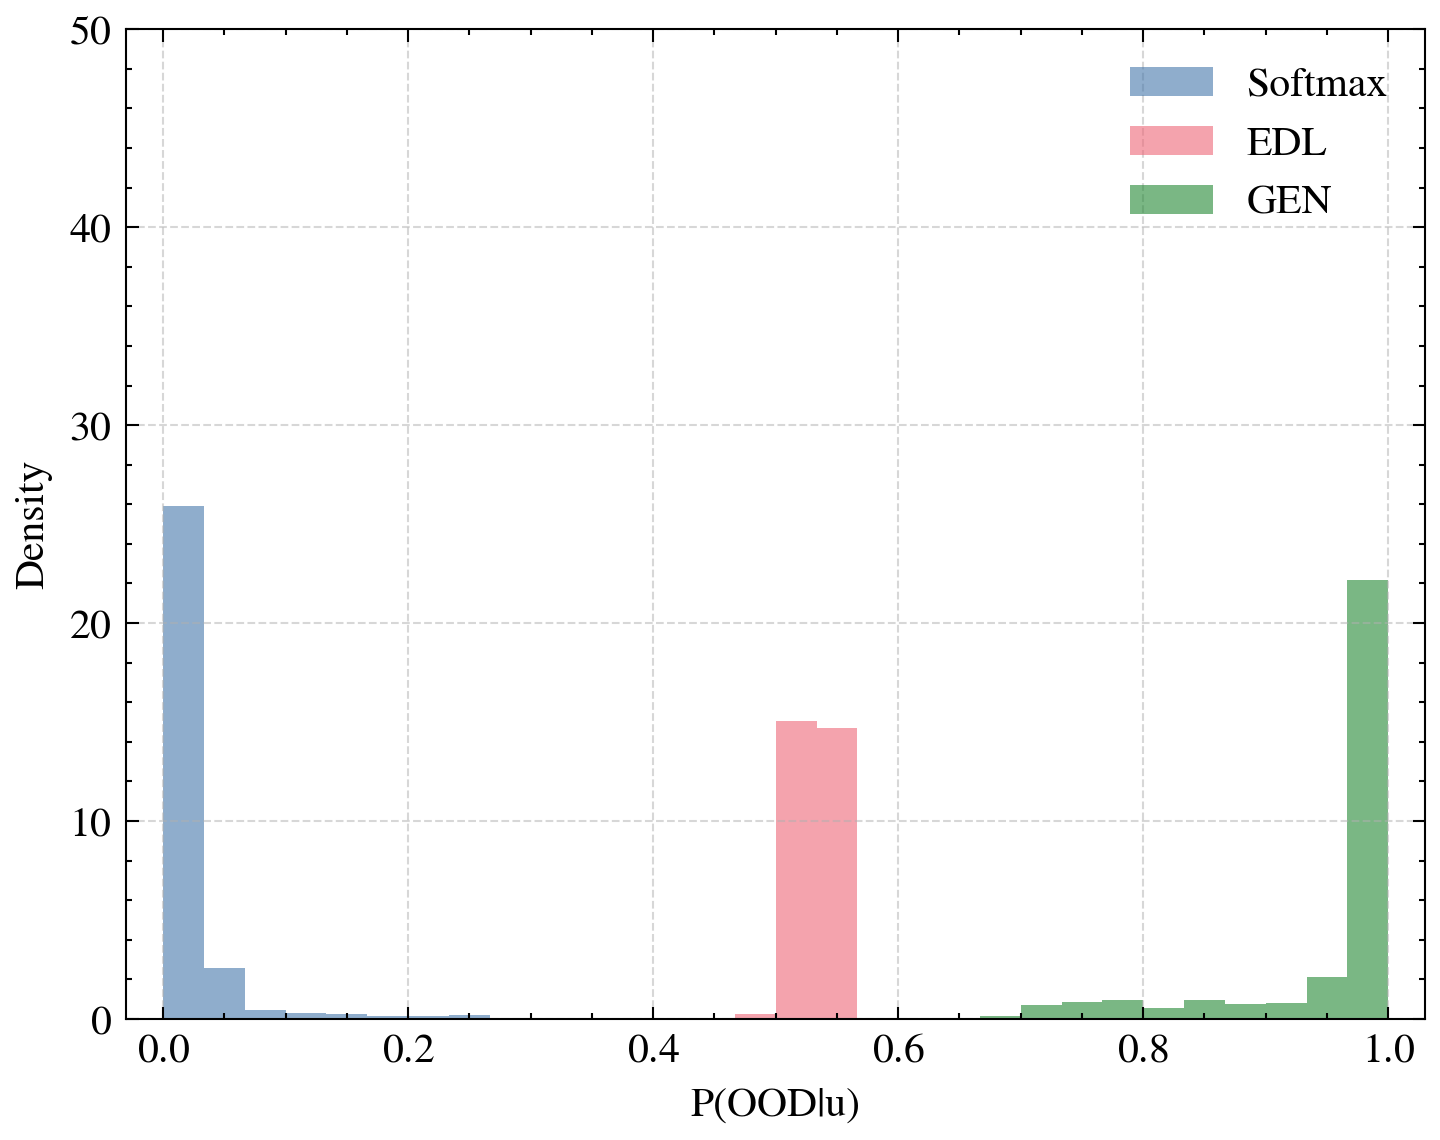

S2c


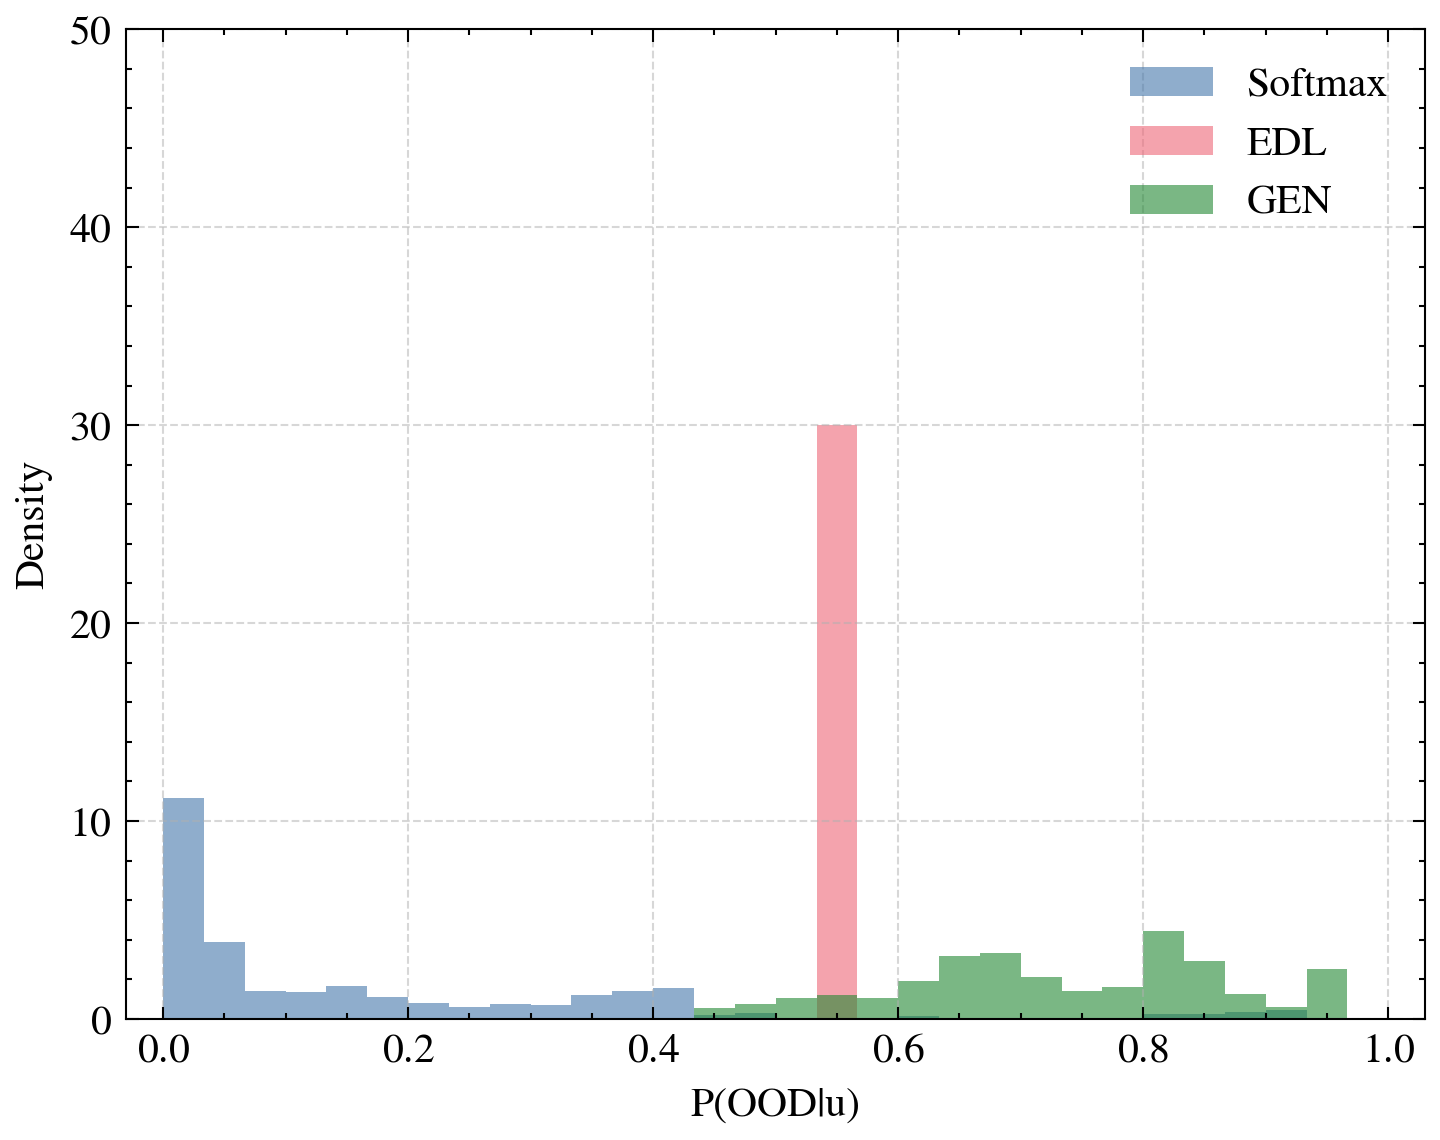

S4a


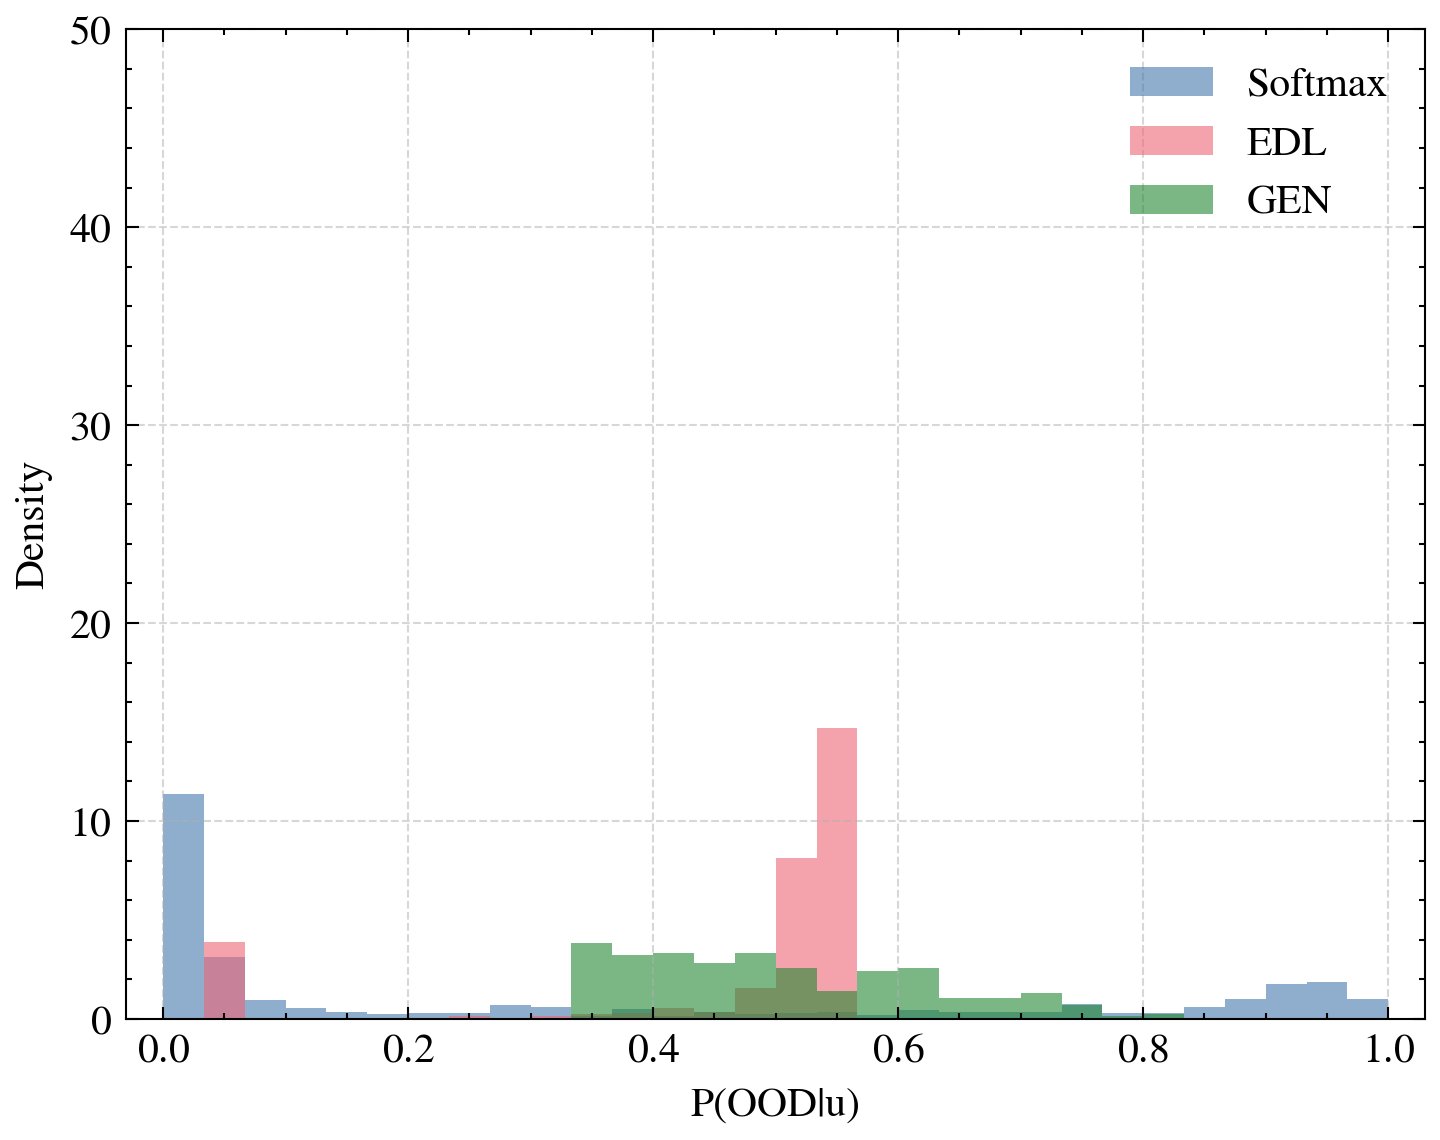

S4b


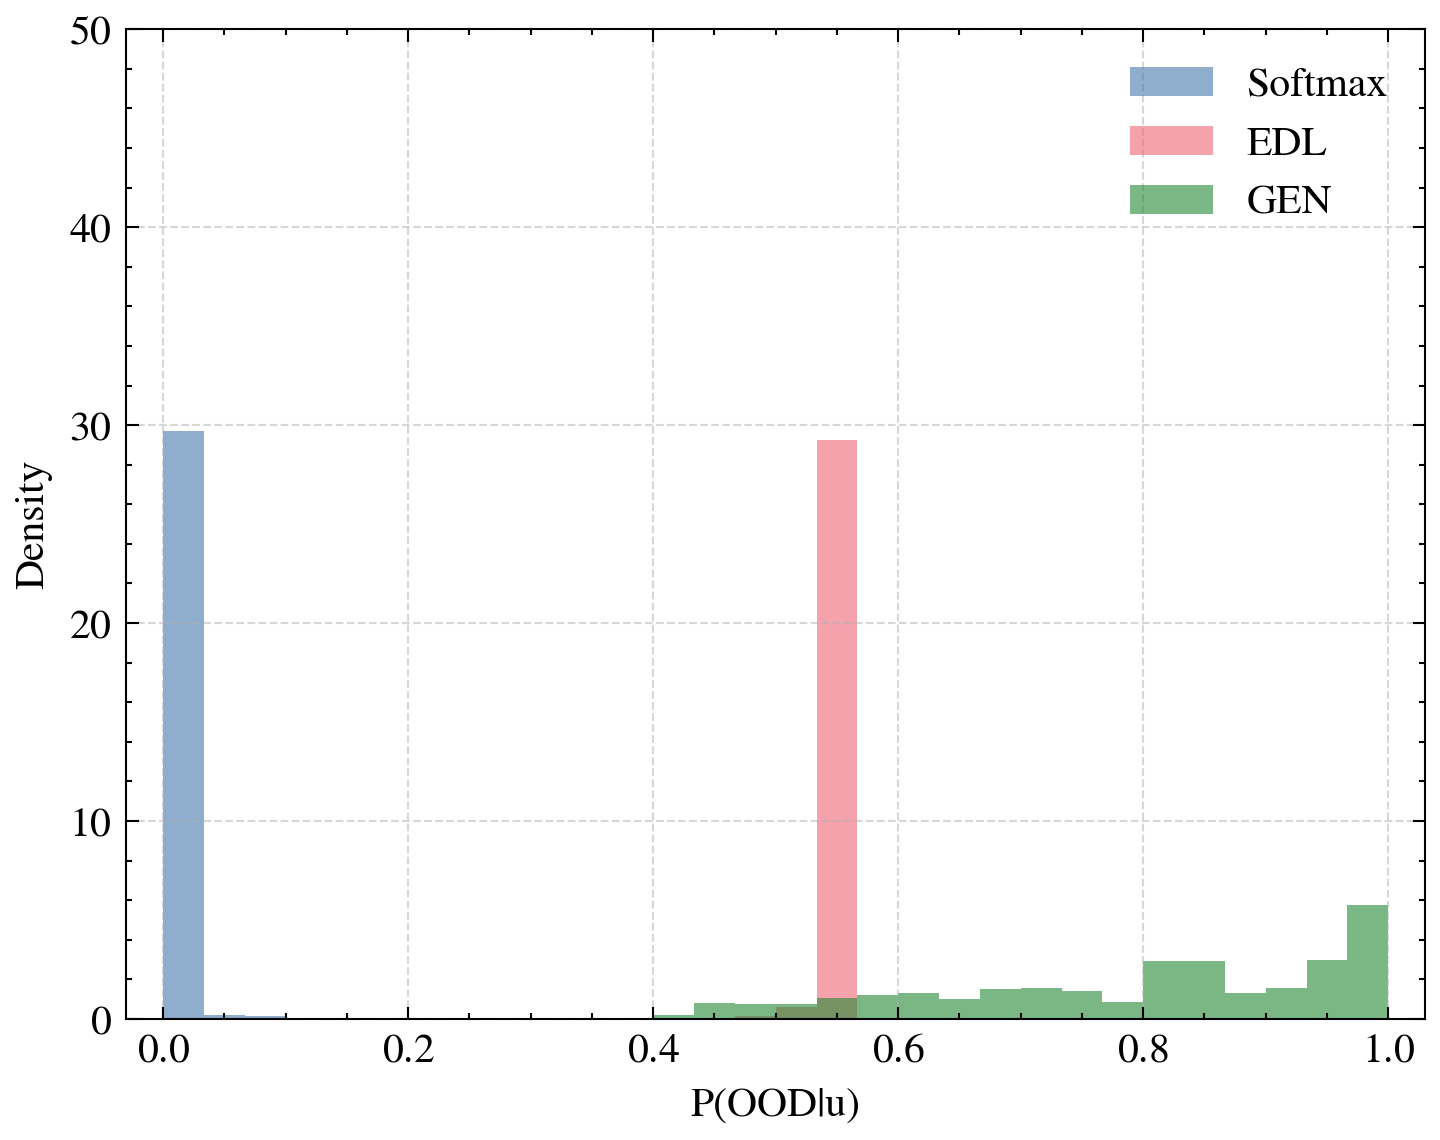

S4c


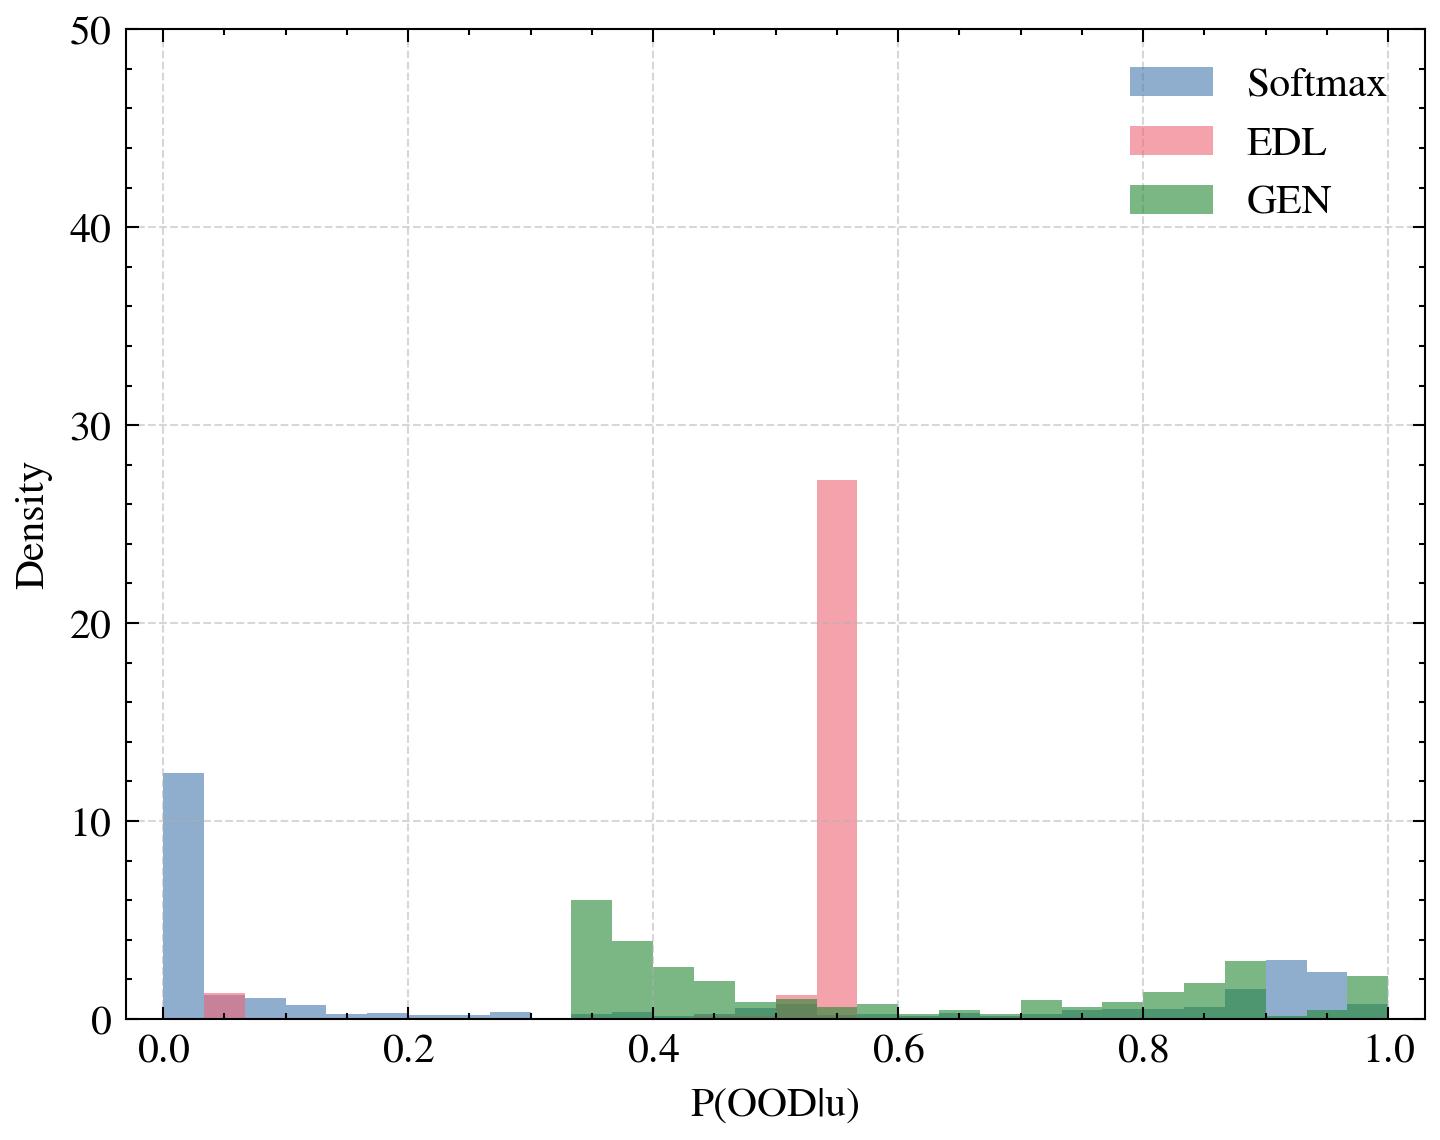

S6a


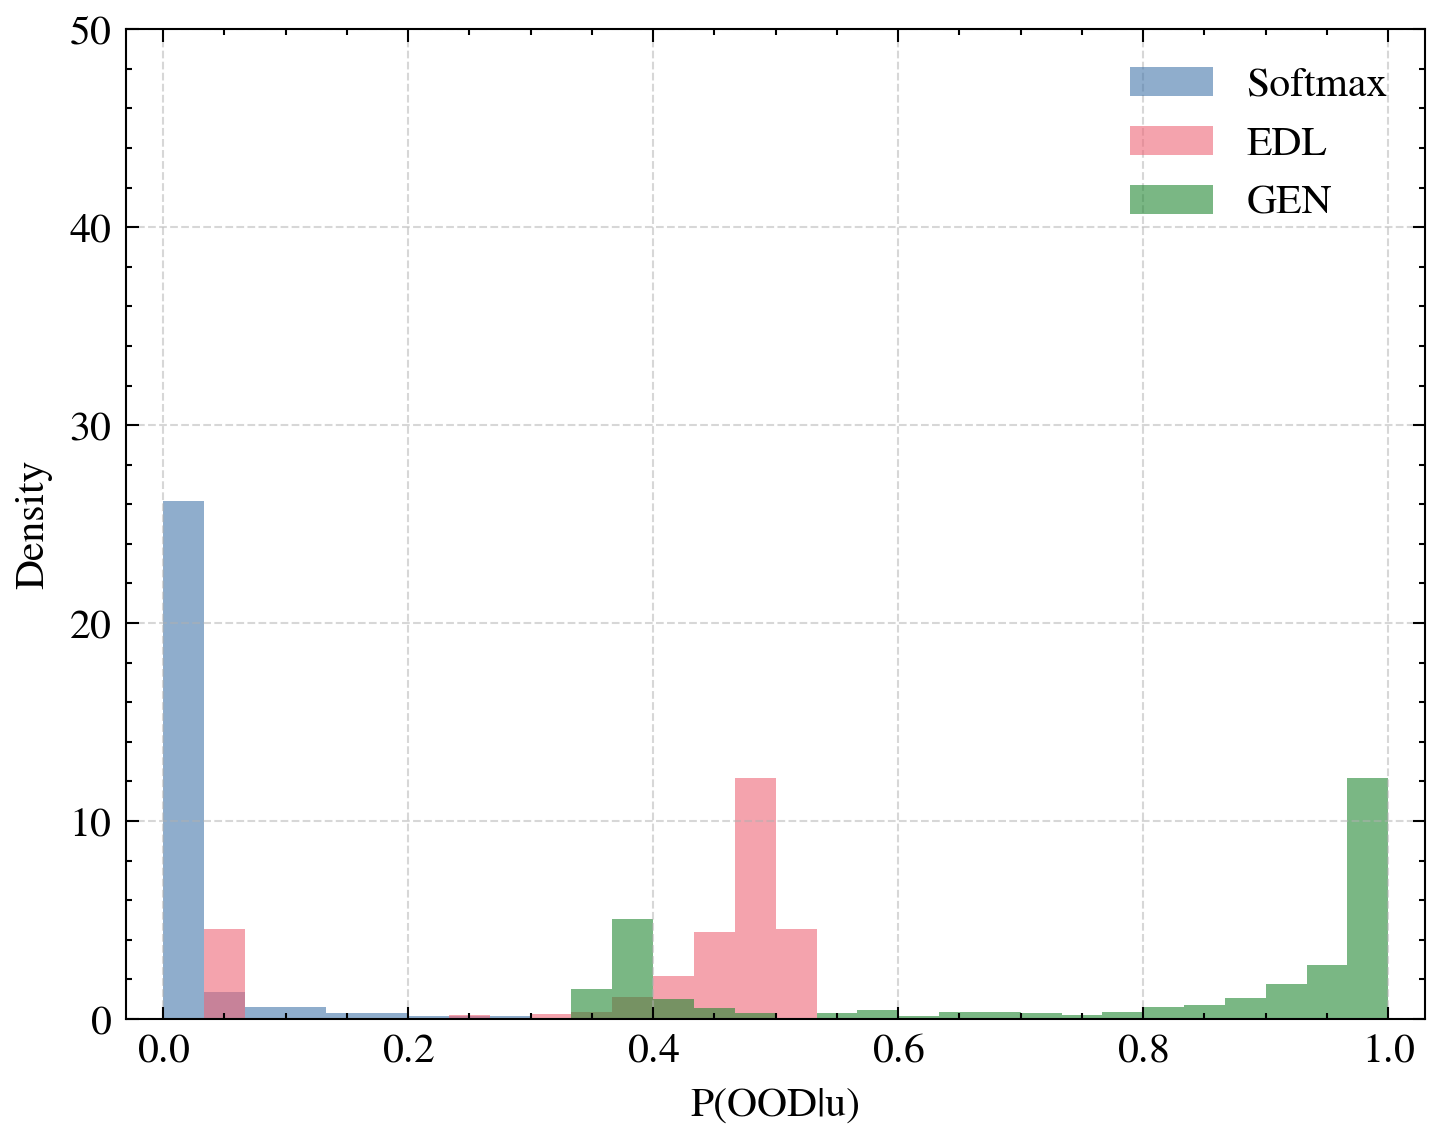

S6b


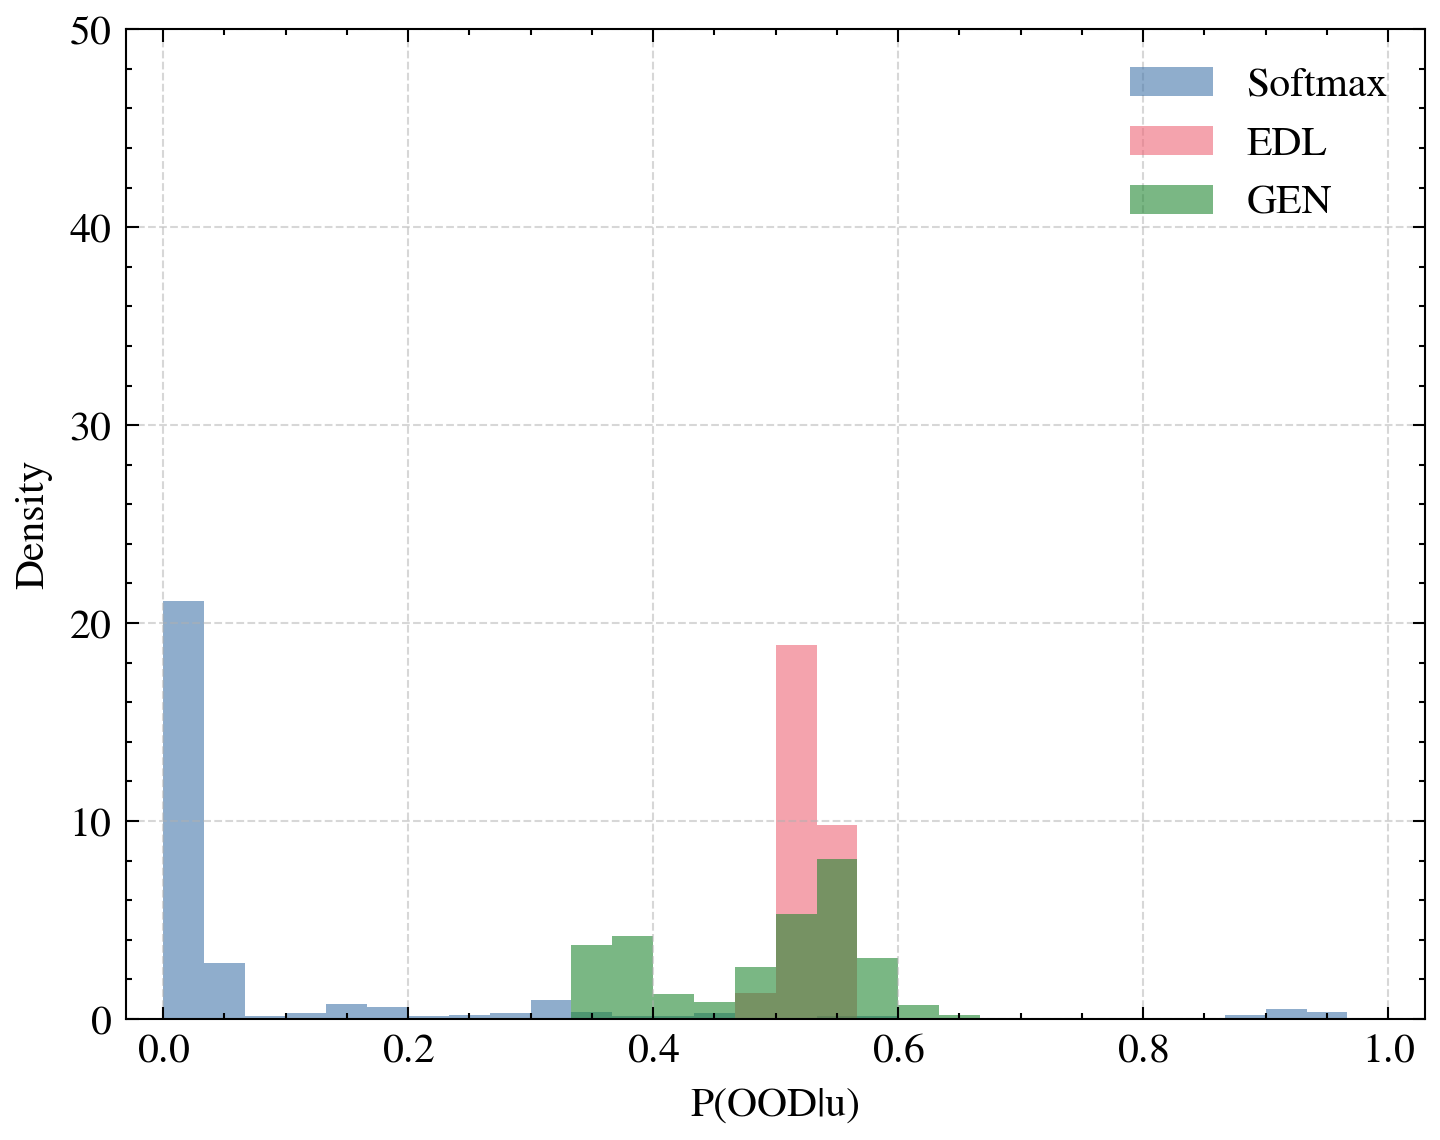

S6c


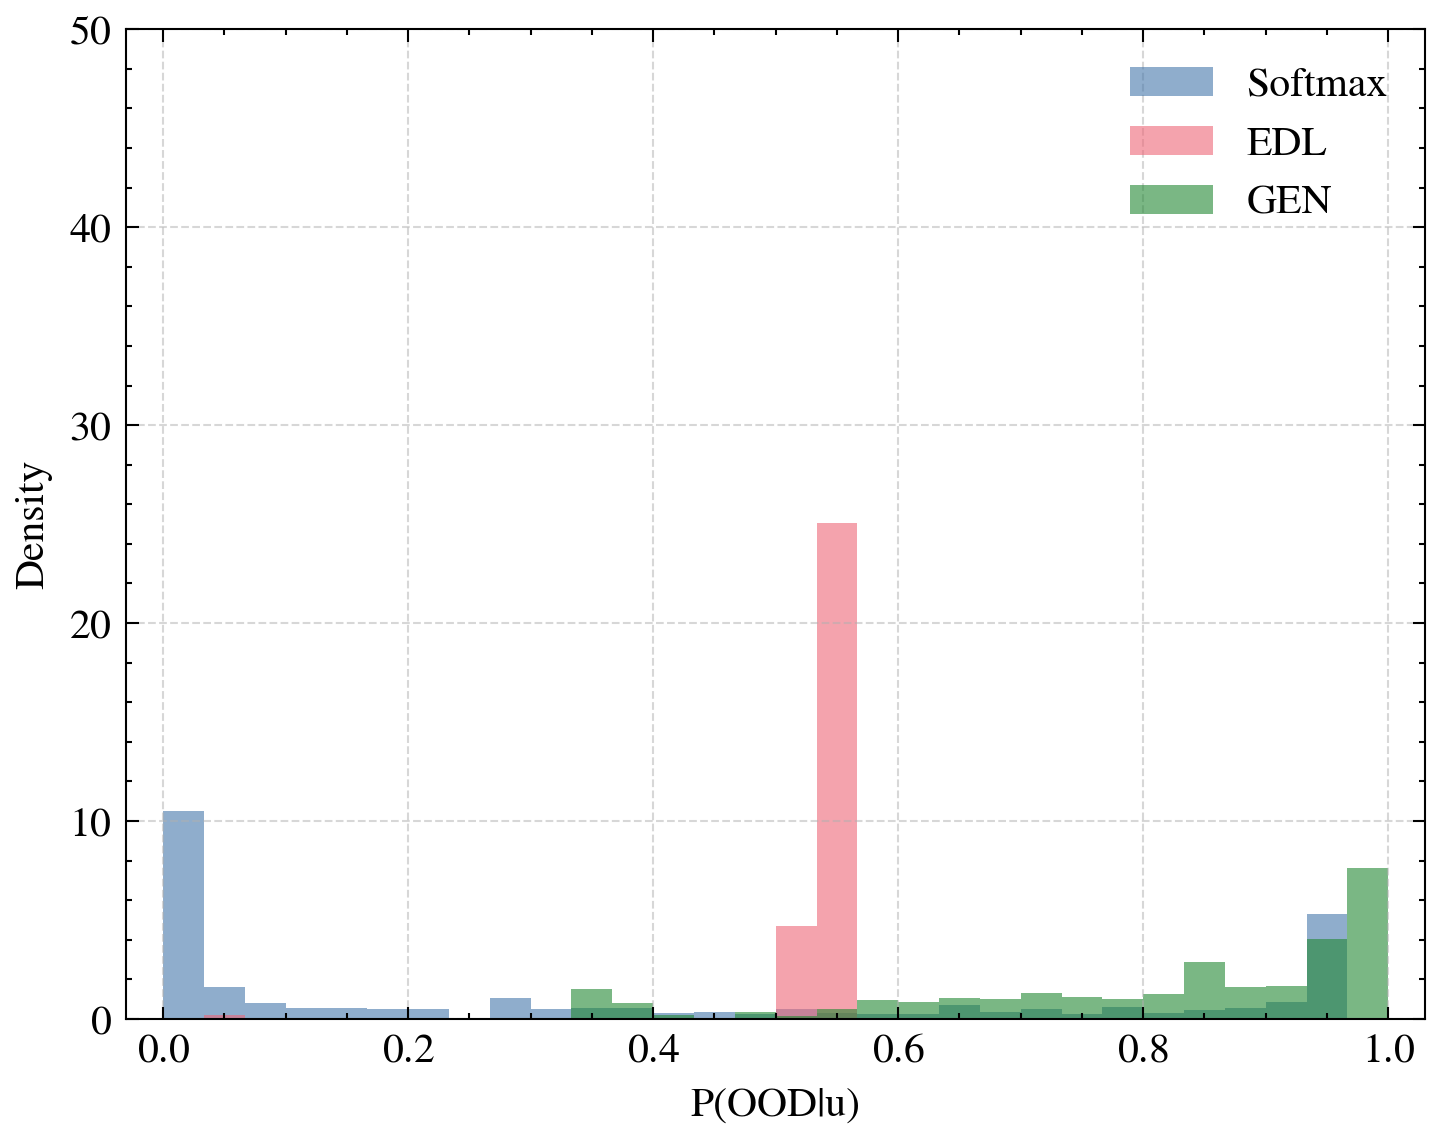

In [27]:
ood_datasets = [(ds.stem, get_ood_dl(ds)) for ds in OOD_DATASETS]

for ood_name, ood_dl in [("ID", test_dl), *ood_datasets]:
    print(ood_name)
    plt.figure(figsize=(5, 4))

    bin_edges = np.linspace(0.0, 1.0, 31)

    for model_name, model_obj, inference_fn in models_list:
        a, b = fit_beta(model_obj, inference_fn, train_dl, DEVICE)

        ood_uncertainties = collect_uncertainties(model_obj, inference_fn, ood_dl, DEVICE)
        ood_scores = bayesian_score(ood_uncertainties, a, b)
        plt.hist(
            ood_scores,
            bins=bin_edges.tolist(),
            range=(0.0, 1.0),
            alpha=0.6,
            label=model_name,
            density=True,
        )

    plt.xlabel("P(OOD|u)")
    plt.xlim(-0.03, 1.03)
    plt.ylabel("Density")
    plt.ylim(0, 50)
    plt.legend()
    plt.grid(True, alpha=0.5, linestyle="--")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"uncertainty_score_hist_{ood_name}.pdf")
    plt.show()

### ROC Curves

In [28]:
def compute_ood_roc(
    model: fusion.Delayed,
    inference_fn: Callable,
    beta_params: tuple[float, float],
    id_dl: torch.utils.data.DataLoader,
    ood_dl: torch.utils.data.DataLoader,
    device: torch.device,
) -> tuple[np.ndarray, np.ndarray, float]:
    """Compute OOD detection ROC using Bayesian P(OOD|u) score.

    Arguments:
        model: The trained model to evaluate.
        inference_fn: Returns (predictions, uncertainties, probabilities).
        beta_params: (a, b) from fit_beta.
        id_dl: DataLoader for in-distribution test set.
        ood_dl: DataLoader for OOD dataset.
        device: Device to run inference on.
        n_points: Number of points for the common FPR grid.

    Returns:
        Tuple (fpr, tpr, auc).

    """
    model.eval()
    a, b = beta_params

    id_uncertainties = collect_uncertainties(model, inference_fn, id_dl, device)
    ood_uncertainties = collect_uncertainties(model, inference_fn, ood_dl, device)

    id_scores = bayesian_score(id_uncertainties, a, b)
    ood_scores = bayesian_score(ood_uncertainties, a, b)

    scores = np.concatenate([id_scores, ood_scores])
    labels = np.concatenate([np.zeros(len(id_scores)), np.ones(len(ood_scores))])

    fpr, tpr, _ = roc_curve(labels, scores)

    return fpr, tpr, float(auc(fpr, tpr))

S1b


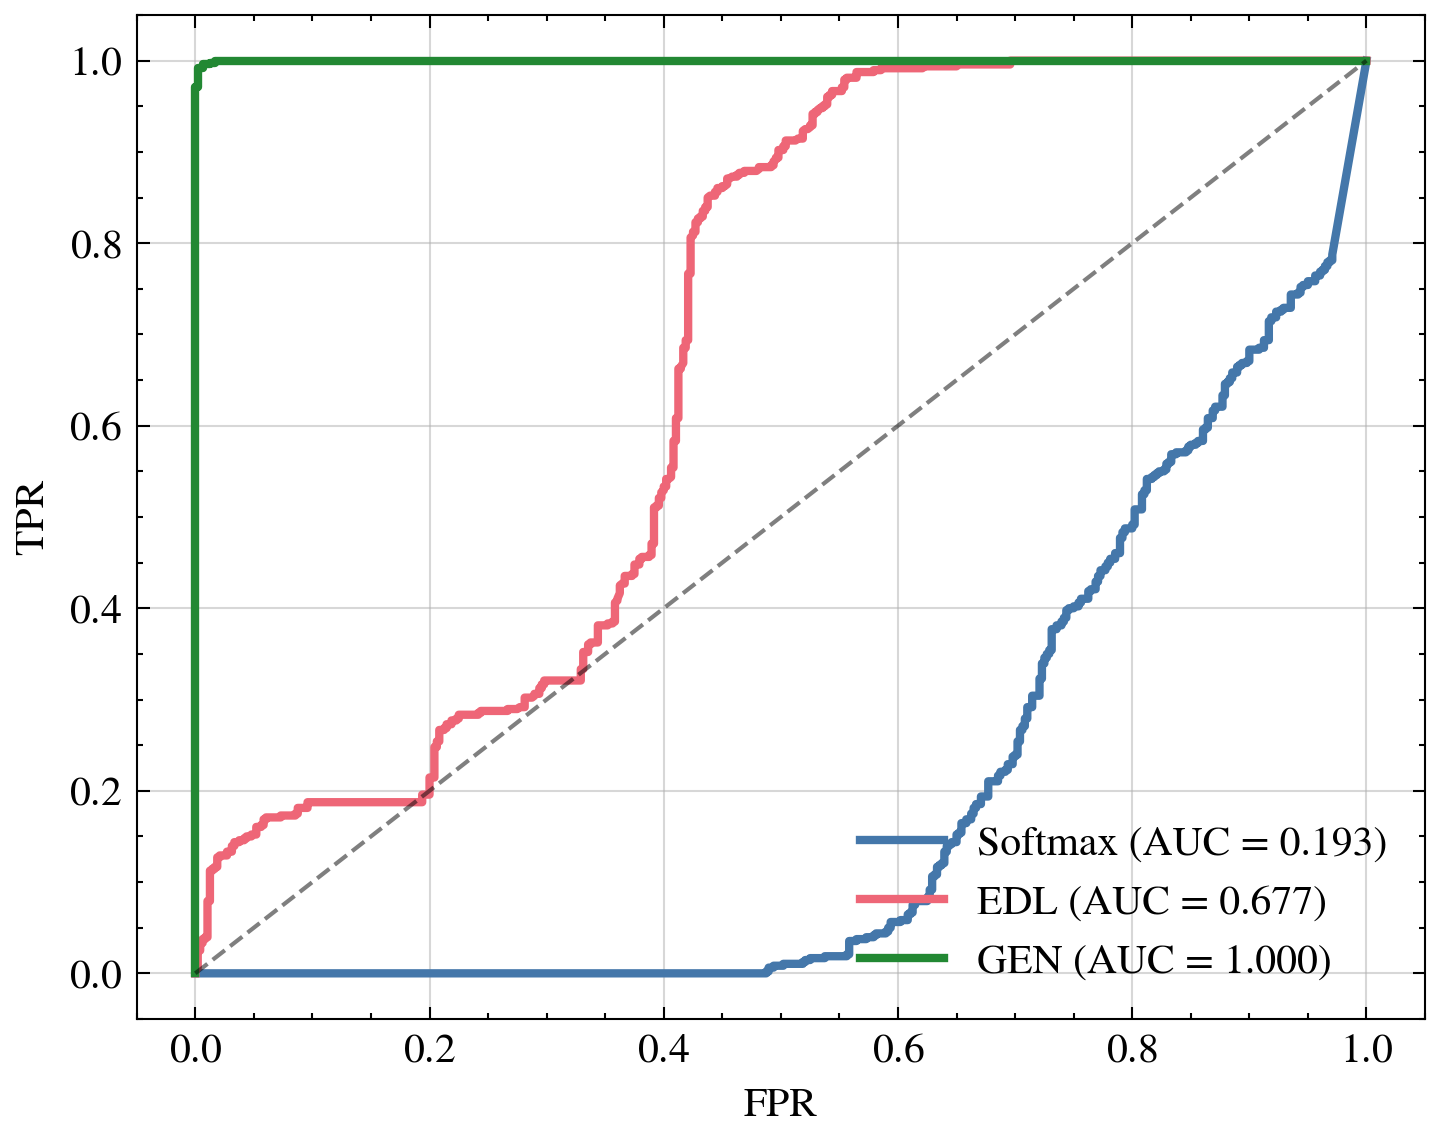

S1c


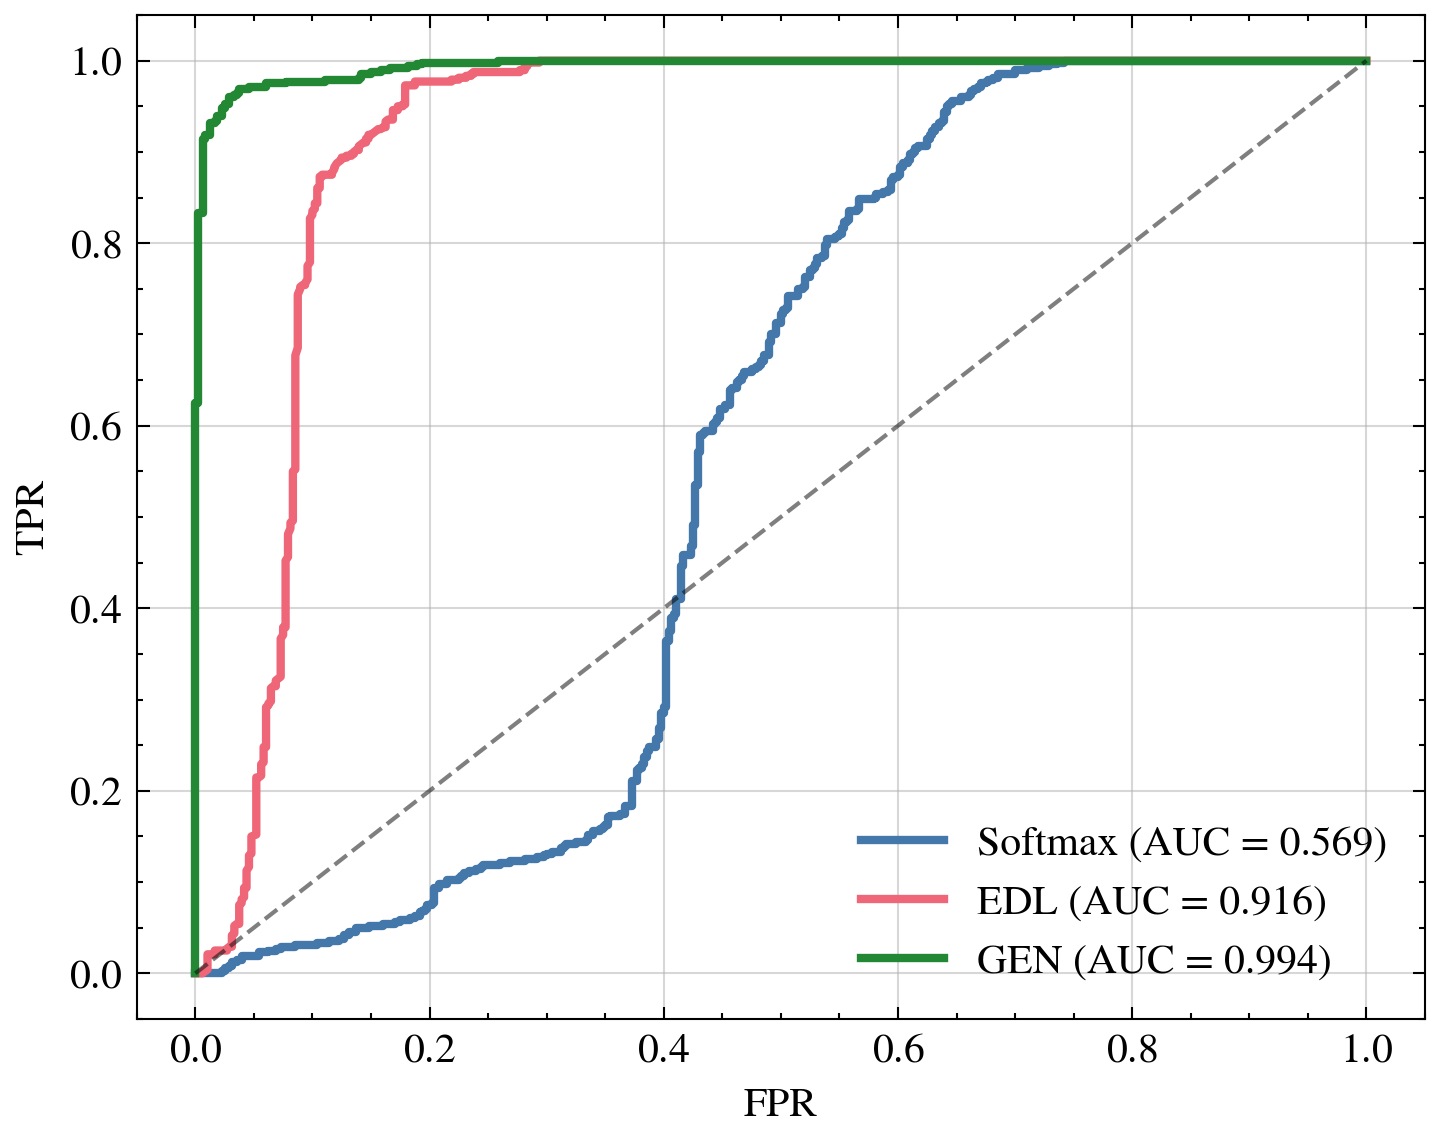

S2a


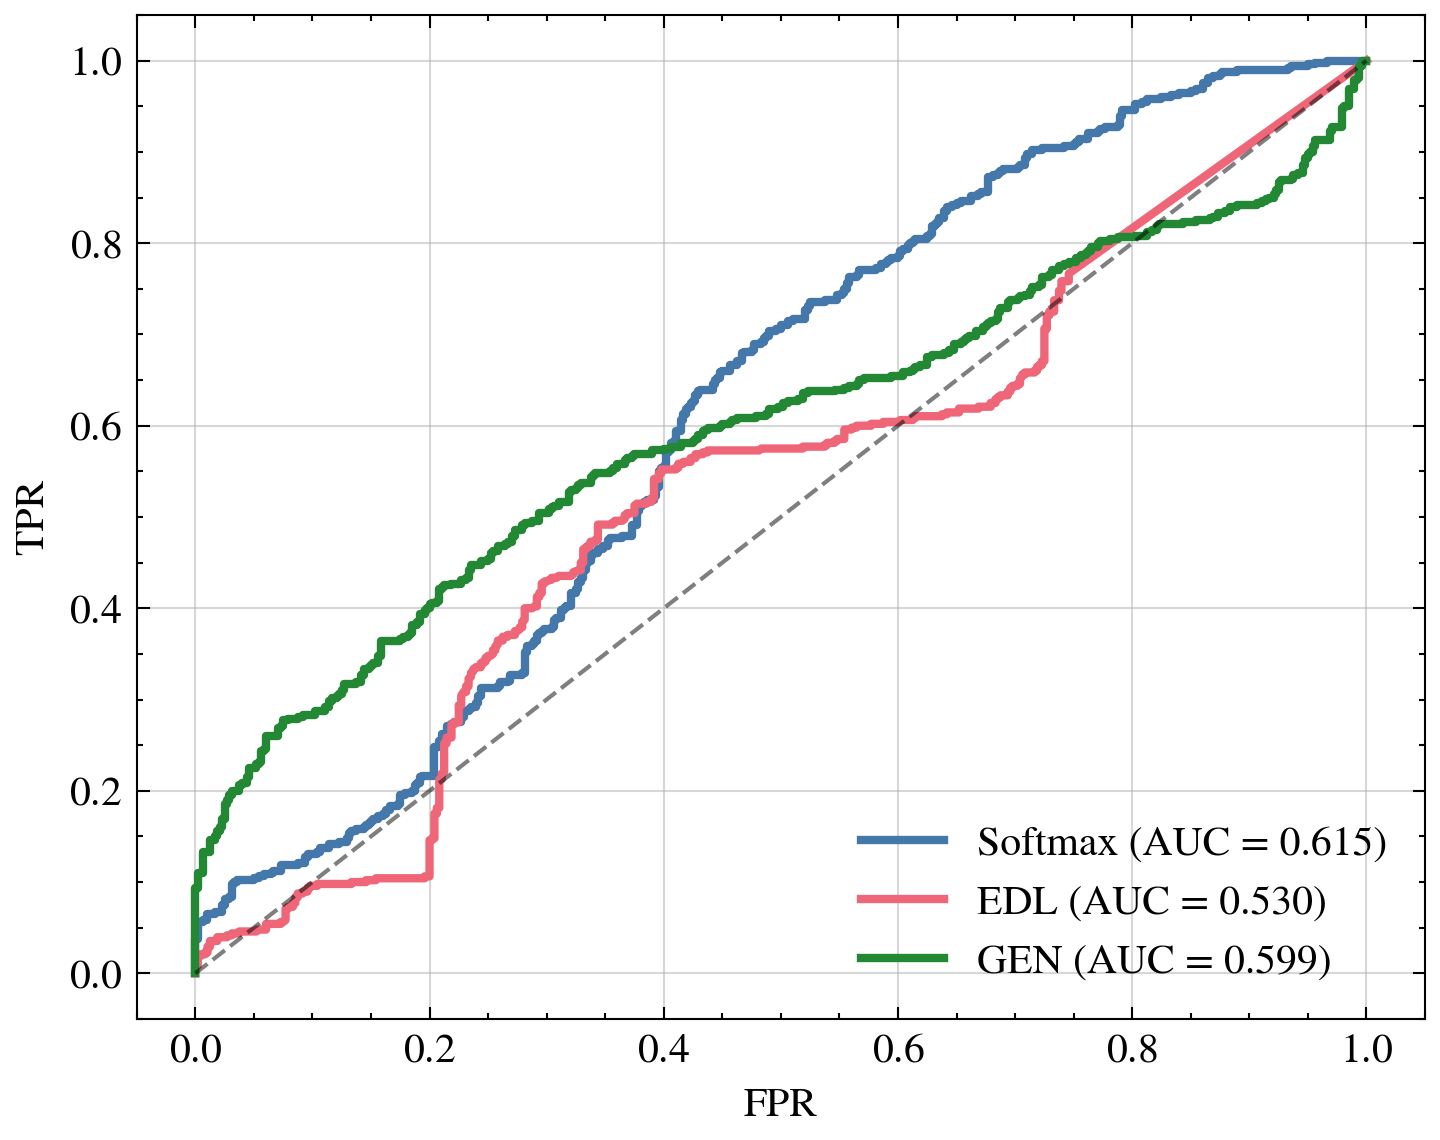

S2b


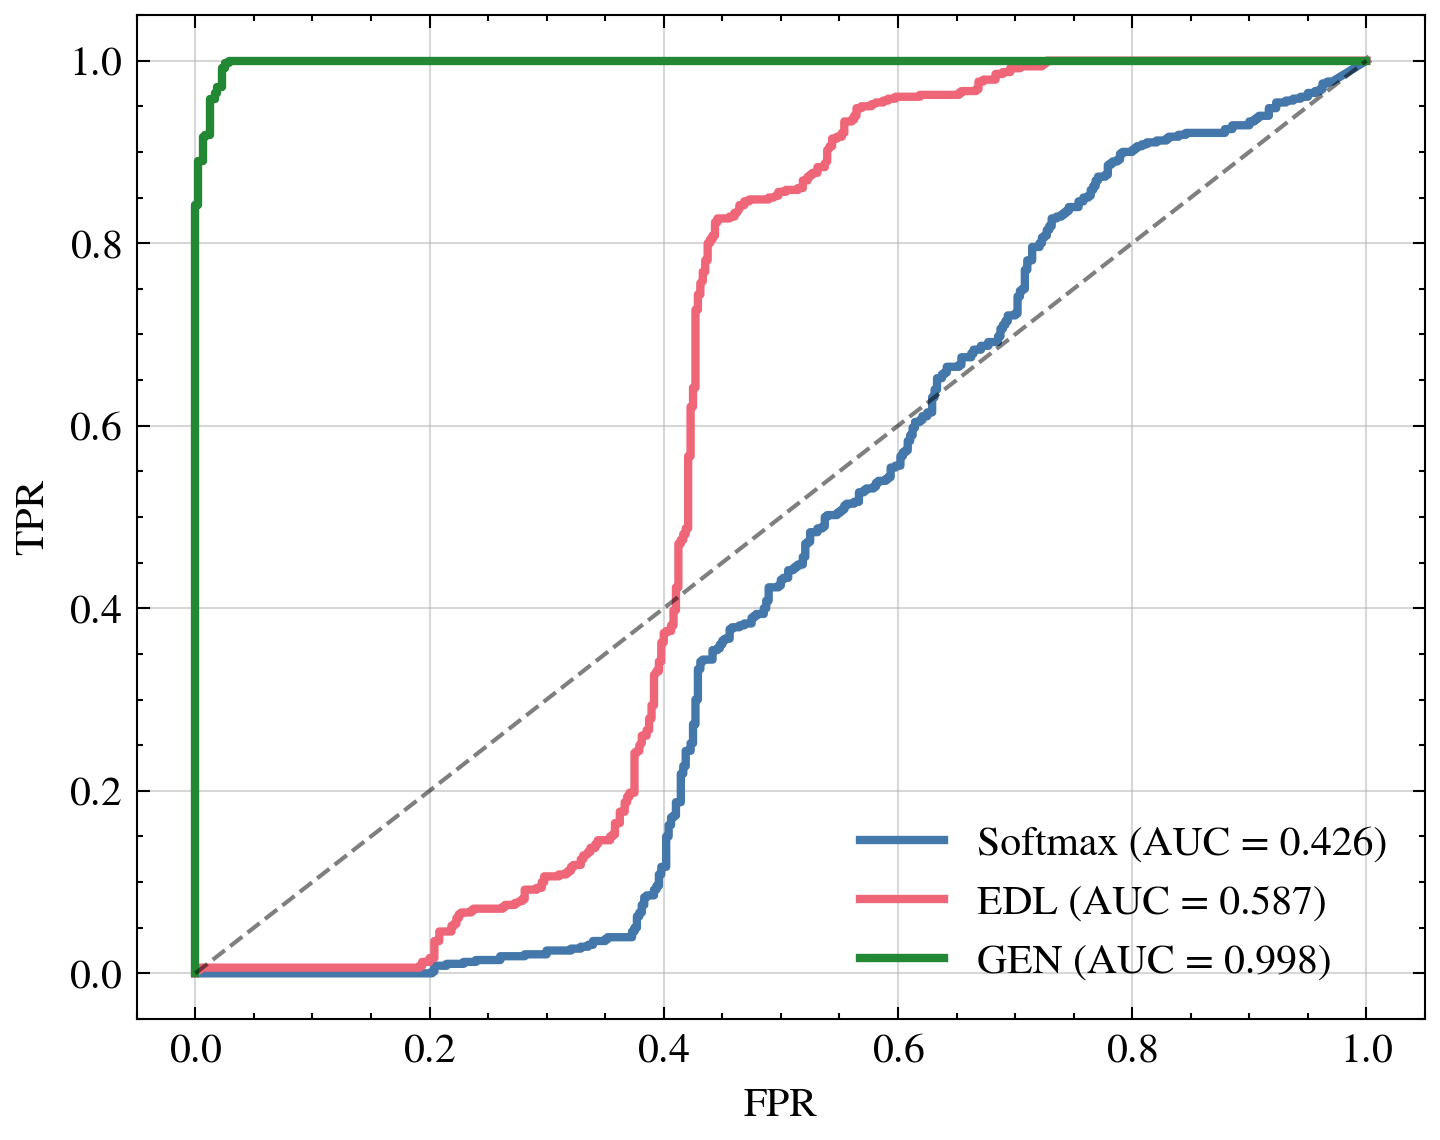

S2c


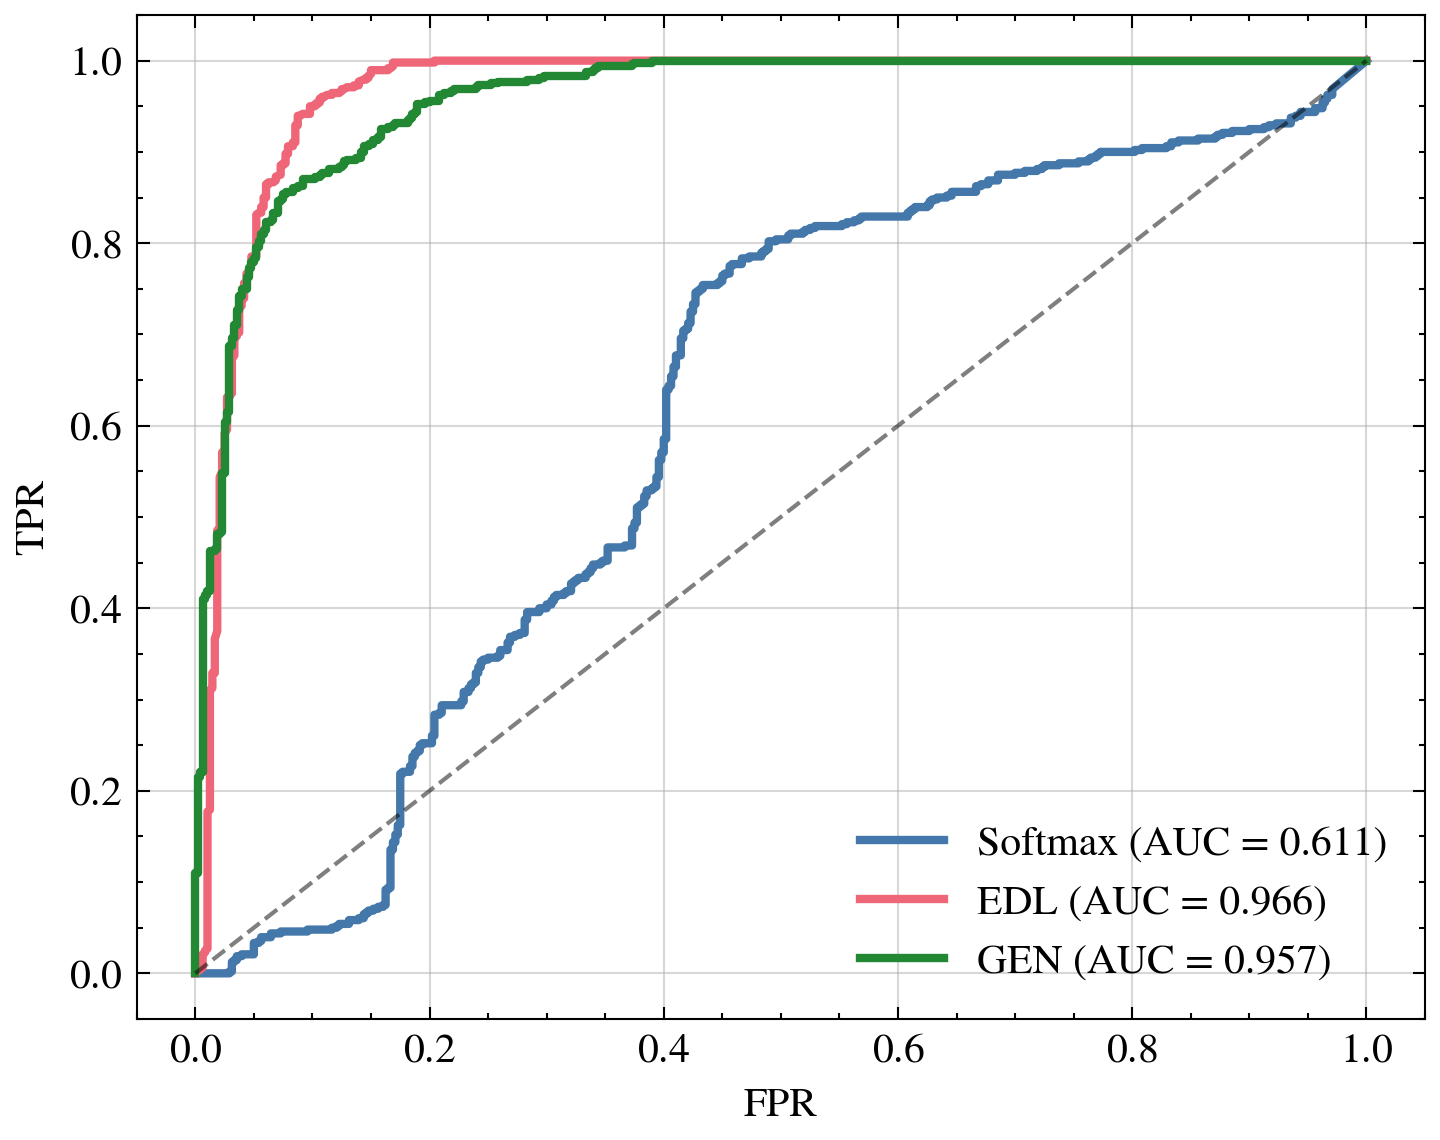

S4a


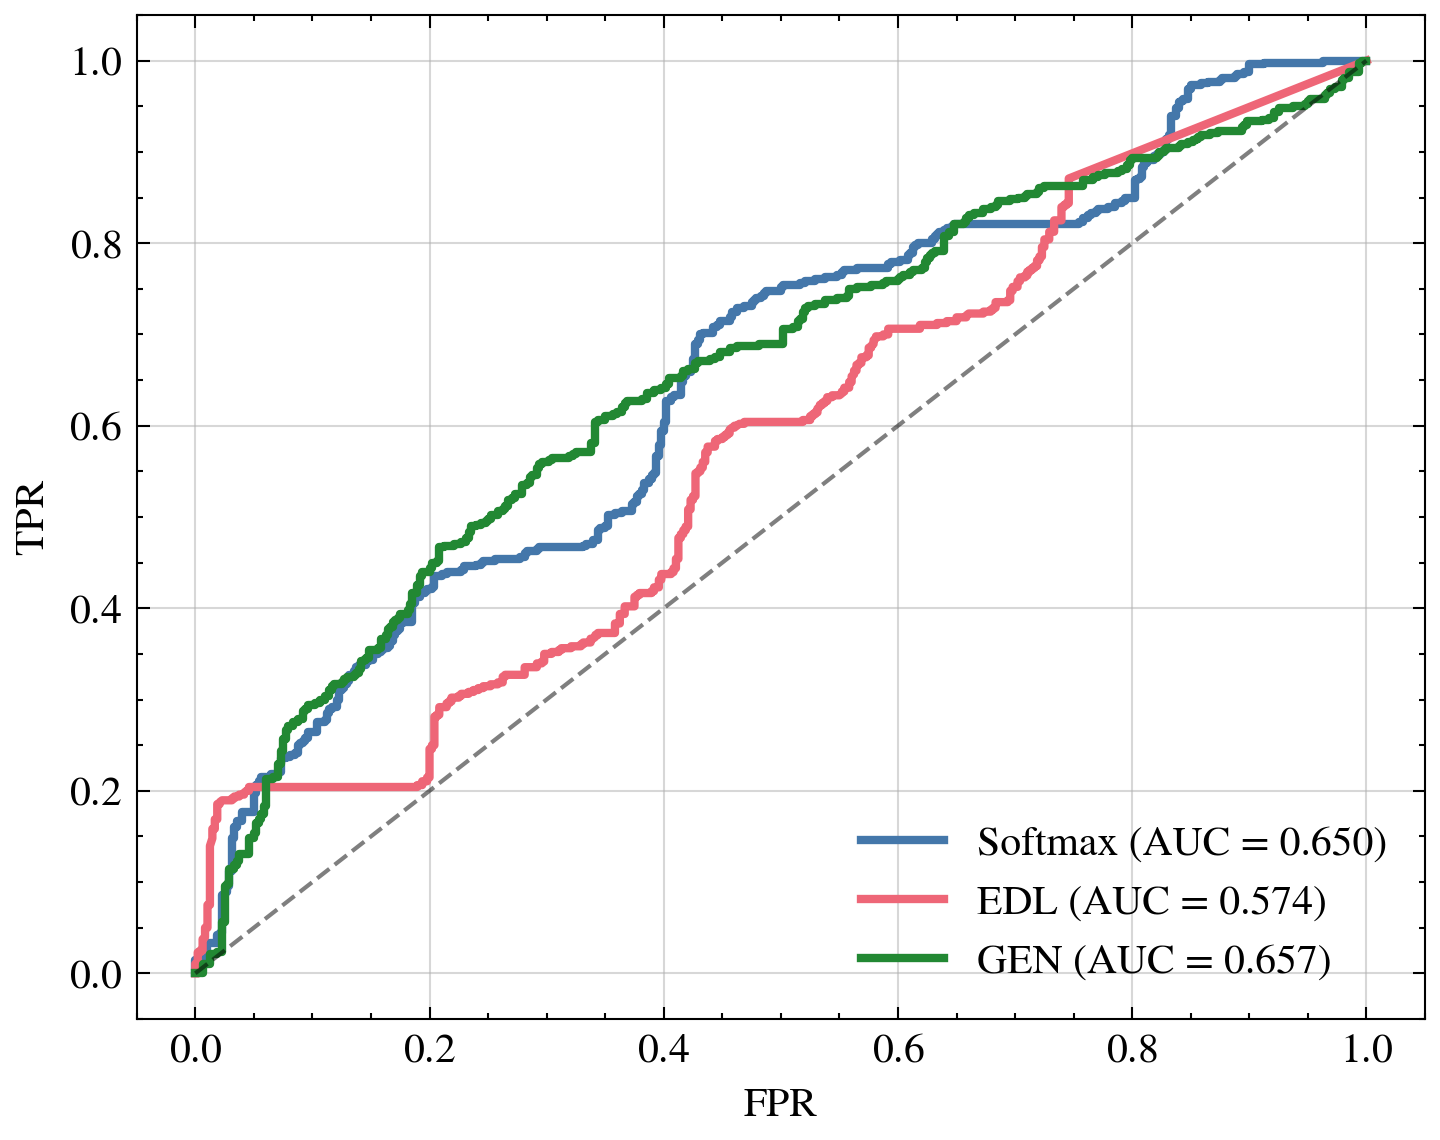

S4b


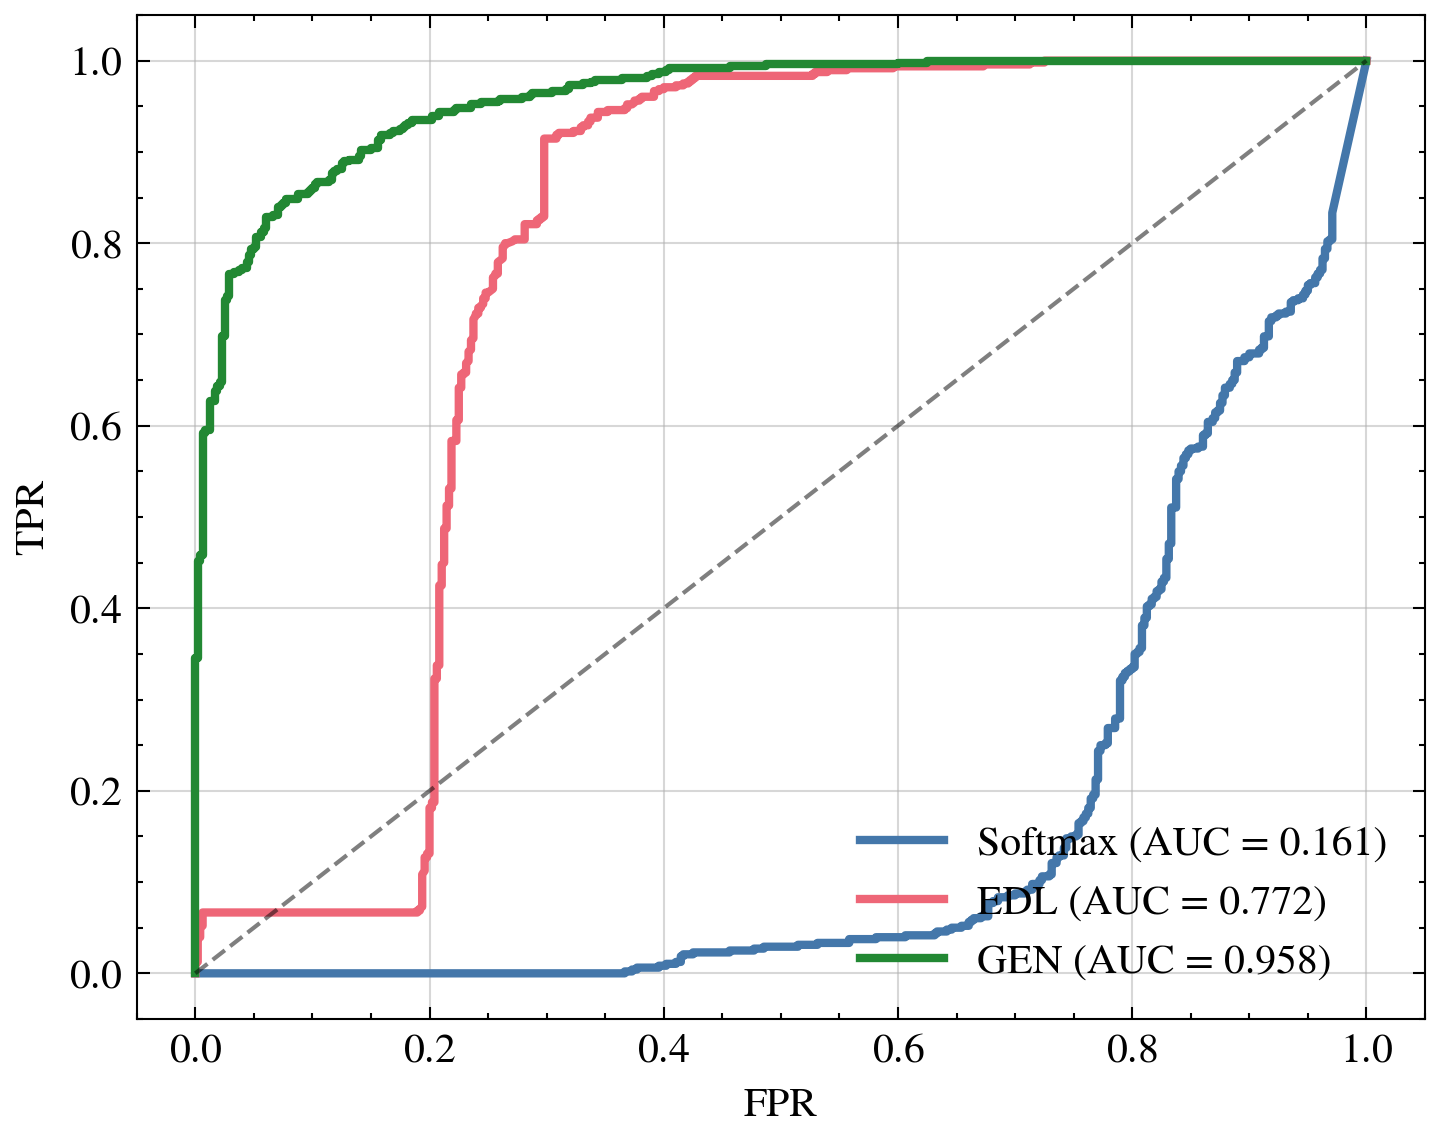

S4c


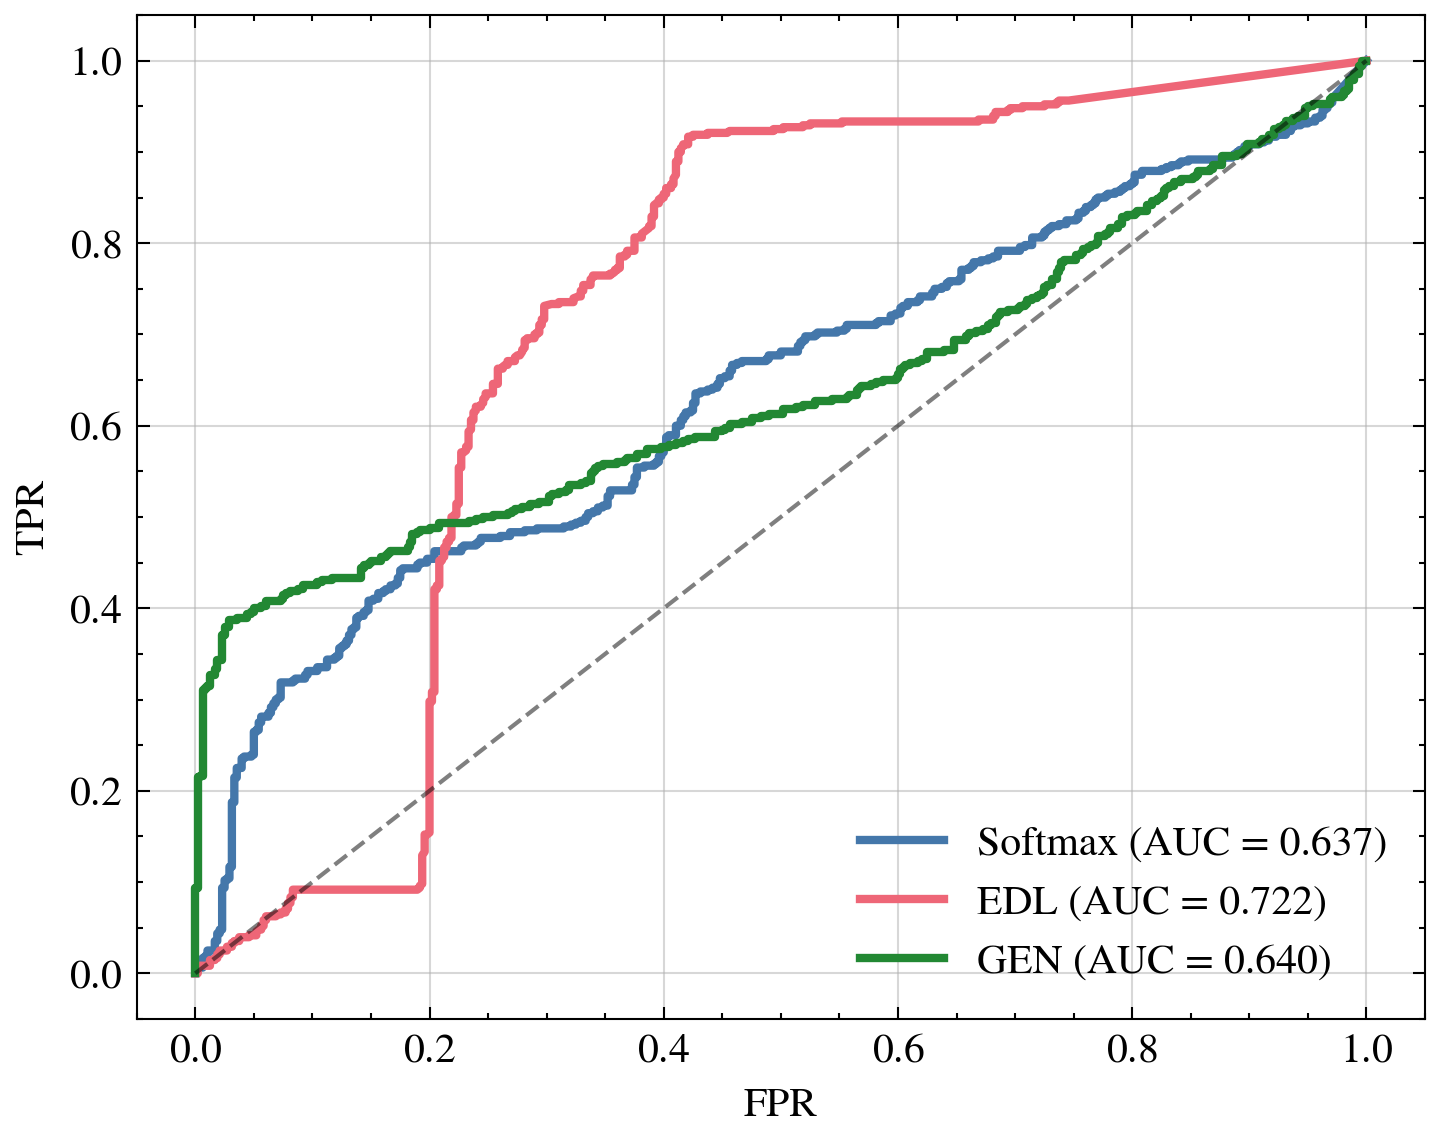

S6a


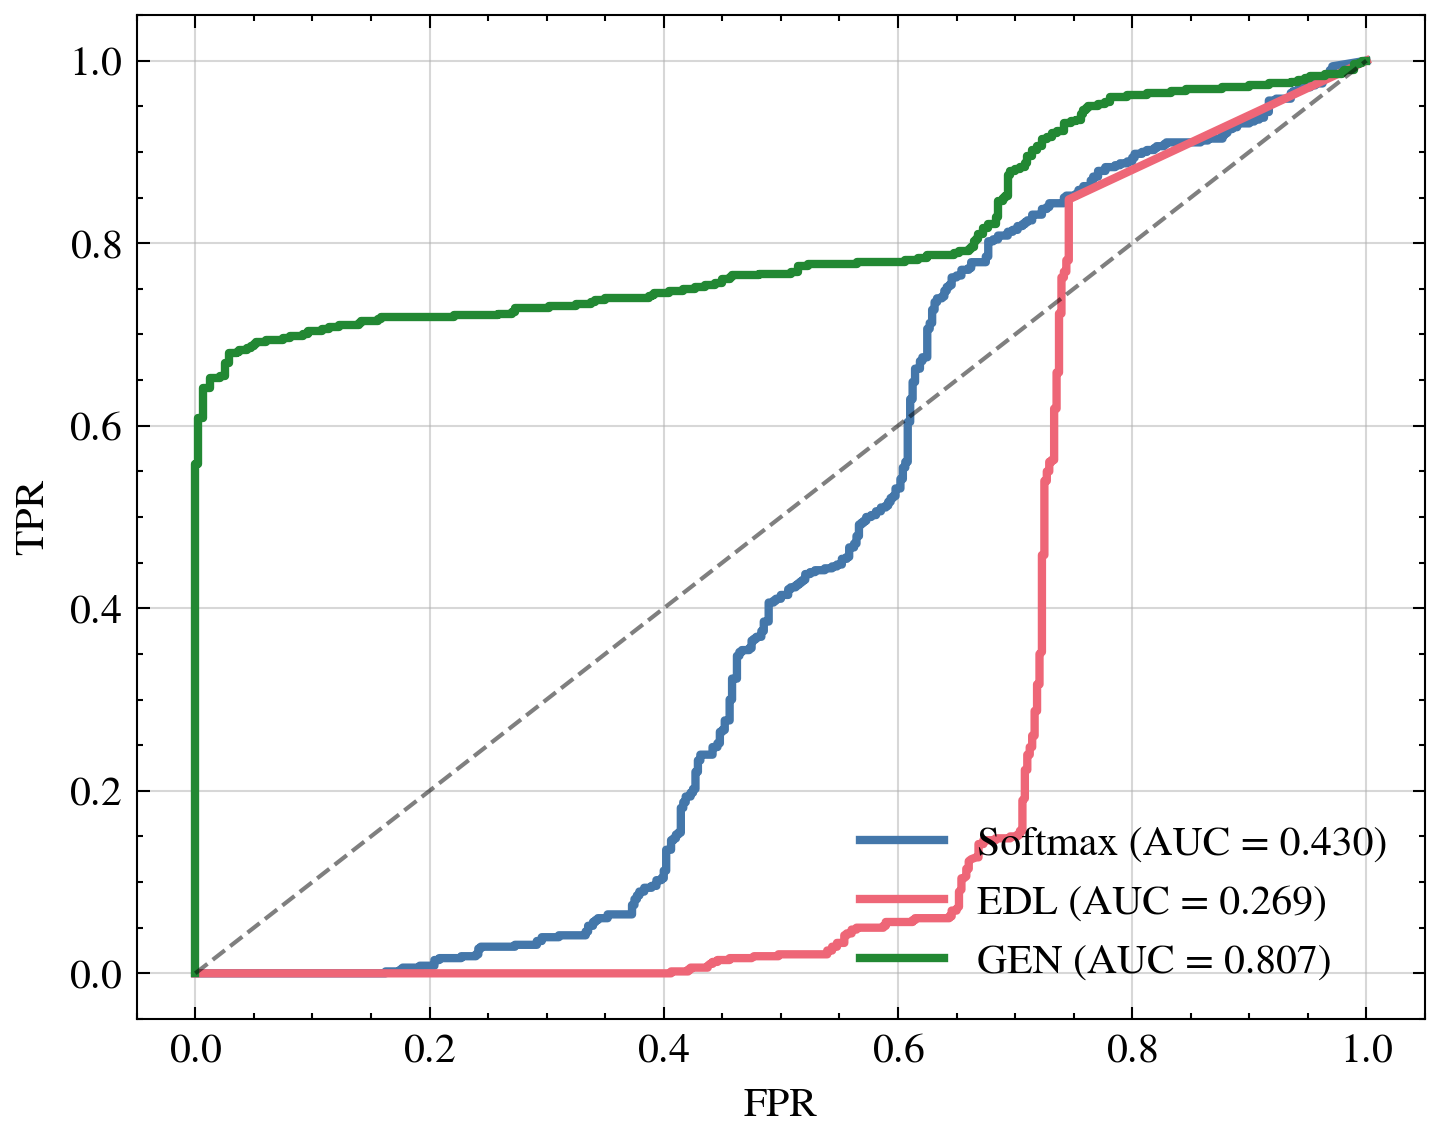

S6b


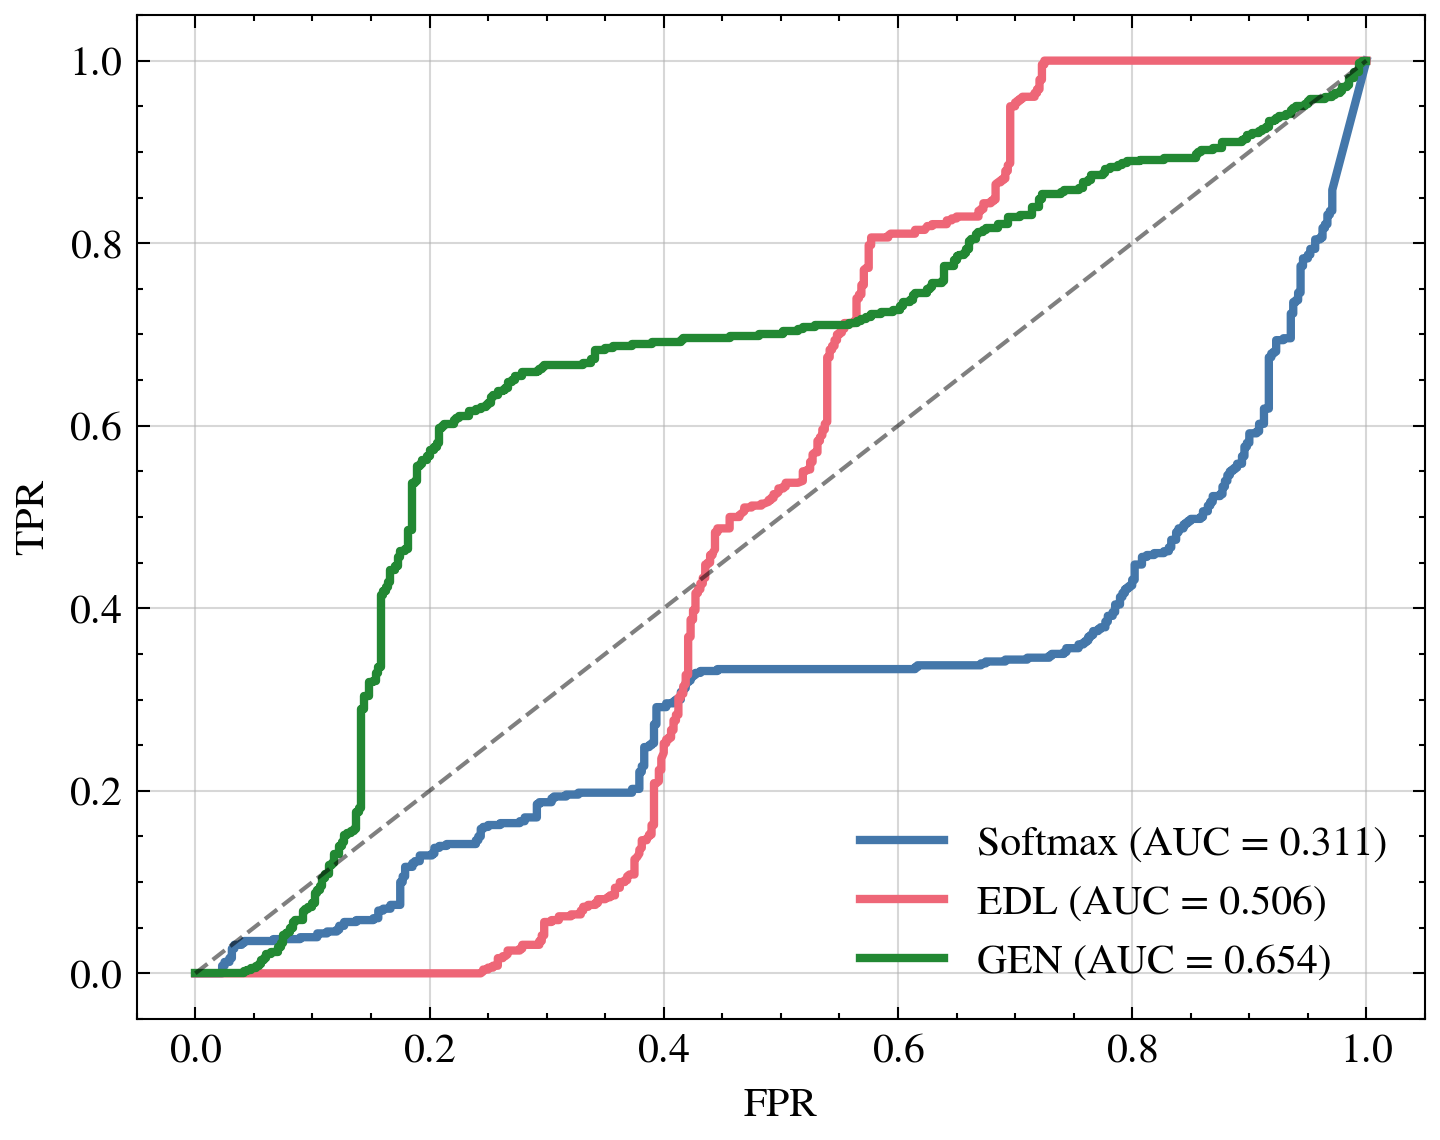

S6c


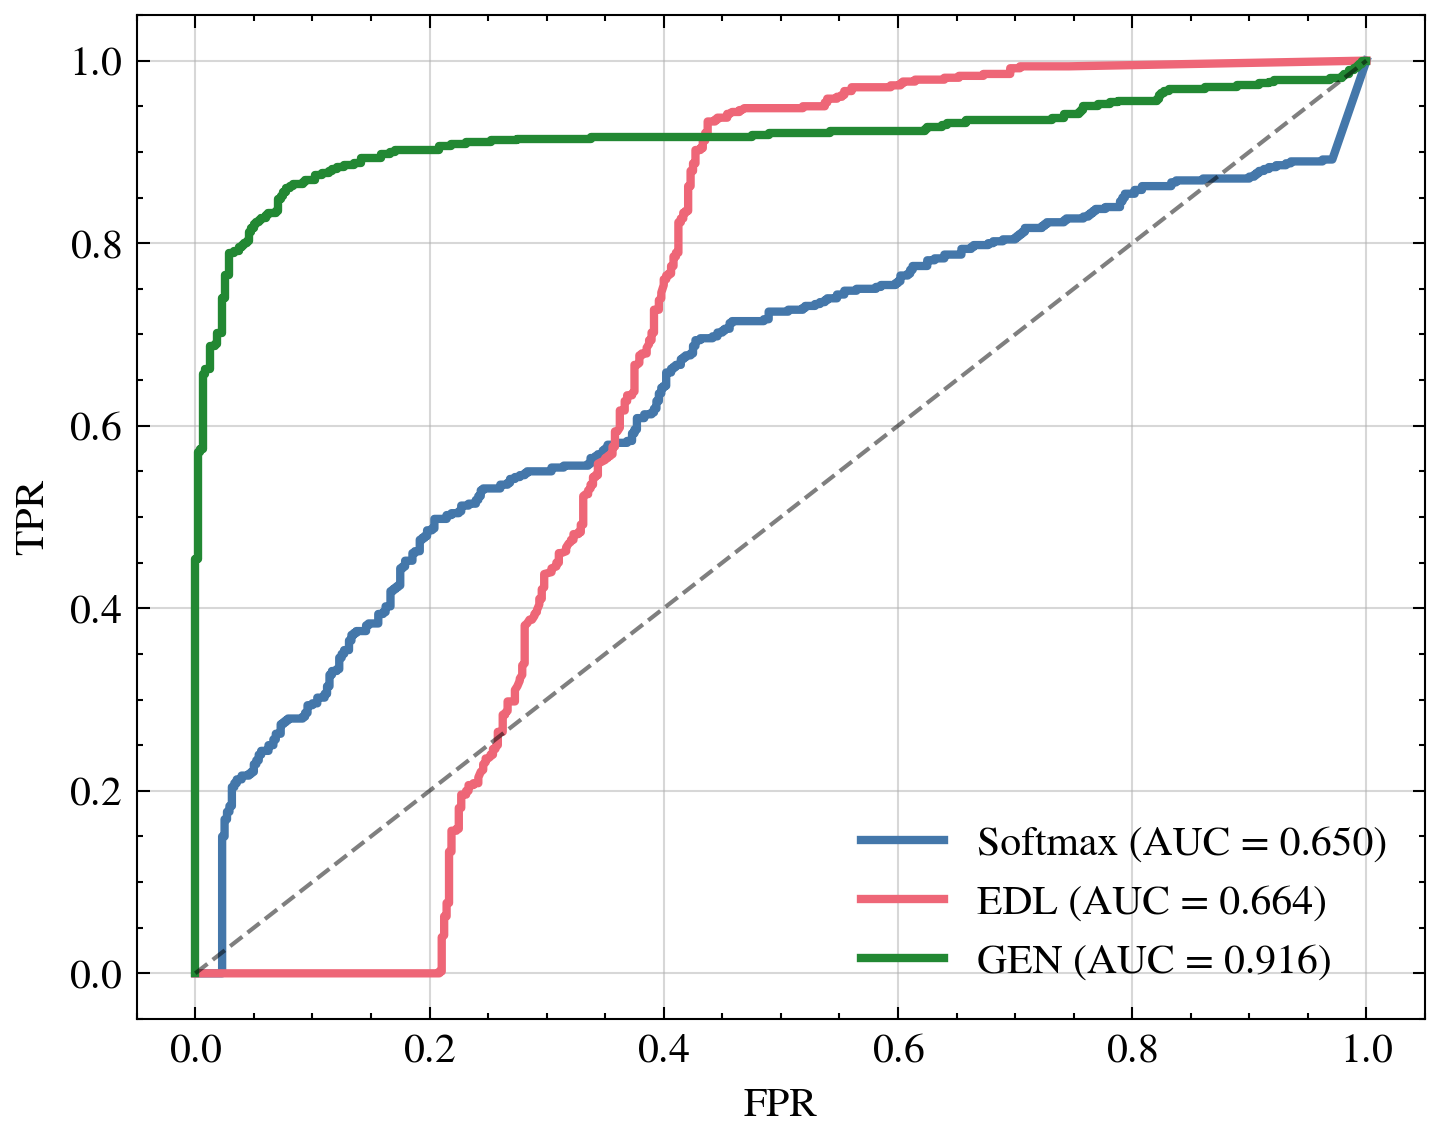

In [29]:
for ood_name, ood_dl in ood_datasets:
    print(ood_name)
    plt.figure(figsize=(5, 4))

    for model_name, model, inference_fn in models_list:

        beta_params = fit_beta(model, inference_fn, train_dl, DEVICE)
        fpr, tpr, roc_auc = compute_ood_roc(model, inference_fn, beta_params, test_dl, ood_dl, DEVICE)

        plt.plot(fpr, tpr, lw=2, label=f"{model_name} (AUC = {roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], color="k", linestyle="--", alpha=0.5)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"edl_roc_{ood_name.lower()}.pdf")
    plt.show()